# Regression Assignment

**Matrikelnummer:** 2130238

**Pre-processing:** `dataset.csv` (Bankkunden-Daten)    
**Datensatz:** `dataset_cleaned.csv` (Bankkunden-Daten)  
**Zielvariable:** `CLV_Continuous` (Customer Lifetime Value)

- **Task 2:** Multiple Lineare Regression
- **Task 3:** Polynomiale Regression (Grad 2 & 3)
- **Task 4:** Modellvergleich & Entscheidung
- **Task 5:** Regularisierung & Optimierung (Ridge & Lasso)
- **Task 6:** Regressionsbaum
- **Task 7:** Modellvergleich
- **Task 8:** Ensemble Learning (Random Forest & XGBoost)

---
## 1. Setup: Bibliotheken, Datensatz & Grundkonfiguration
Alle benötigten Bibliotheken werden einmalig importiert und der Datensatz geladen und Konstanten deklariert. Anschließend wird die Feature-Matrix `X` und die Zielvariable `y` bestimmt sowie der Train-Test-Split definiert und in allen folgenden Aufgaben wiederverwendet.

In [1]:
# ── Bibliotheken ─────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import (
    KFold, GridSearchCV, train_test_split,
    cross_val_score, learning_curve
)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rc('font', size=13)
plt.rc('axes', labelsize=13, titlesize=13)
plt.rc('legend', fontsize=12)

# ── Datensatz laden ───────────────────────────────────────────────────────────
df = pd.read_csv('../data/dataset_cleaned.csv')

# ── Konstanten ────────────────────────────────────────────────────────────────
TEST_SIZE    = 0.2 # d.h.: 80 % Training / 20 % Test
RANDOM_STATE = 42
K_FOLD_SPLITS = 5

In [2]:
# Feature-Matrix & Zielvariable
X = df.drop(['Churn', 'CLV_Continuous'], axis=1)  # alle Spalten außer Churn & CLV_Continuous
y = df['CLV_Continuous']

print(f"Feature-Matrix X: {X.shape}")
print(f"Zielvariable y:    {y.shape}")

Feature-Matrix X: (8521, 22)
Zielvariable y:    (8521,)


Ein 80/20-Split wurde gewählt, da Regressionsmodelle von einer größeren Trainingsmenge profitieren und kein Klassenungleichgewicht eine besondere Berücksichtigung im Testset erfordert.

In [3]:
# Train-Test-Split (momentan: 80 % / 20 %)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)

# Ausgabe
print(f"\nTrainingsdaten:  {X_train.shape[0]} Zeilen, {X_train.shape[1]} Spalten")
print(f"Testdaten:       {X_test.shape[0]} Zeilen, {X_test.shape[1]} Spalten")


Trainingsdaten:  6816 Zeilen, 22 Spalten
Testdaten:       1705 Zeilen, 22 Spalten


---
## Task 2: Multiple Lineare Regression

**Ziel:** Aufbau eines multiplen linearen Regressionsmodells zur Vorhersage des Customer Lifetime Value (`CLV_Continuous`).

**Ansatz & Motivation**
> **Multiple lineare Regression** (MLR) ist das natürliche Startmodell für Regressionsaufgaben mit mehreren Eingangsgrößen.  
Sie modelliert die Zielvariable als gewichtete Linearkombination der Features:

$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \ldots + \beta_n x_n$$

**Annahmen des Modells:**
- Linearer Zusammenhang zwischen Features und Zielvariable
- Keine perfekte Multikollinearität zwischen den Features
- Residuen sind normalverteilt und homoskedastisch (gleichmäßige Streuung)

**Motivation für diesen Datensatz:**
- `CLV_Continuous` ist stetig und nahezu normalverteilt → ideal für lineare Regression
- Als Baseline-Modell dient MLR als Referenzpunkt für alle weiteren Aufgaben (Polynomial, Ridge/Lasso, Regressionsbaum)
- Keine Regularisierung wird in Task 2 erwartet (laut Aufgabenstellung)

### Modell trainieren und prädizieren

Wir verwenden eine **multiple lineare Regression** mit der Klasse `LinearRegression()` aus `sklearn`.

**Warum dieses Verfahren und nicht SGD?**
- Bei rund 8.500 Beobachtungen und 22 Features ist das Verfahren rechnerisch unkritisch
- Kein zwingendes Feature-Scaling erforderlich
- Es müssen keine Lernraten oder Epochen feinjustiert werden

**Was gibt der Koeffizient (β) an?**
- Gibt an, um wie viel sich die Zielvariable ändert, wenn das zugehörige Feature um 1 Einheit steigt – bei konstantem Wert aller anderen Features.

In [4]:
# Lineares Regressionsmodell erstellen
lin_reg = LinearRegression()

# Modell auf Trainingsdaten trainieren
lin_reg.fit(X_train, y_train)

# Vorhersagen auf Trainingsdaten
predictions_train = lin_reg.predict(X_train)

# Vorhersagen auf Testdaten
predictions_test = lin_reg.predict(X_test)

In [5]:
# Intercept (Bias-Term β0)
print(f"Intercept (β0): {lin_reg.intercept_:.4f}")

# Top k Koeffizienten
k = 5

# Koeffizienten (Feature Weights β1...βn)
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Koeffizient': lin_reg.coef_
}).sort_values('Koeffizient', ascending=False)

print(f"\nTop {k} Koeffizienten (sortiert nach Größe):")
print(coef_df[:k].to_string(index=False))

Intercept (β0): 426.1005

Top 5 Koeffizienten (sortiert nach Größe):
             Feature  Koeffizient
     CIsActiveMember  1251.441179
      CNumOfProducts  1245.672172
          CHasCrCard   817.324380
CBalance_is_negative    50.503358
  Account_Age_Months    48.879036


**Interpretation der Koeffizienten:**

Ein Hinweis vorab: Die rohen Koeffizienten sind nur bedingt vergleichbar, weil die Features sehr unterschiedliche Skalen haben – `CIsActiveMember` ist binär (0/1), `CBalance` geht bis 250.000 €. Ein großer Koeffizient bedeutet also nicht automatisch, dass ein Feature "wichtiger" ist. Für eine direkte Vergleichbarkeit bräuchte man einen StandardScaler (wie später in Task 5 bei Ridge/Lasso).

Was sich trotzdem ablesen lässt: Features mit positivem Koeffizient (z.B. `CIsActiveMember`, `CNumOfProducts`) tragen positiv zum vorhergesagten CLV bei, negative Koeffizienten wirken senkend. Mehr lässt sich ohne Skalierung nicht sicher sagen.

### Ergebnis-Vergleich: Train vs. Test

Wir berechnen folgende Metriken:
- **MAE** (Mean Absolute Error): Durchschnittlicher absoluter Fehler in der Originaleinheit (€)
- **MSE** (Mean Squared Error): Mittlerer quadratischer Fehler, der große Fehler stärker bestraft
- **RMSE** (Root Mean Squared Error): Wurzel aus MSE, wieder in Originaleinheit (€) interpretierbar
- **R²** (Bestimmtheitsmaß): Anteil der erklärten Varianz (0 = nichts erklärt, 1 = perfekt)
- **Adjusted R²**: Bereinigtes R², das die Anzahl der Prädiktoren berücksichtigt

Die Evaluation auf den **Testdaten** zeigt, wie gut das Modell auf **unbekannte Daten** generalisiert. Das ist die entscheidende Kennzahl für die Modellgüte in Machine Learning.

In [6]:
# Adjusted R² berechnen
n_train = X_train.shape[0]
k = X_train.shape[1]
adj_r2_train = 1 - (1 - r2_score(y_train, predictions_train)) * (n_train - 1) / (n_train - k - 1)

n_test = X_test.shape[0]
adj_r2_test = 1 - (1 - r2_score(y_test, predictions_test)) * (n_test - 1) / (n_test - k - 1)

# Zusammenfassende Vergleichstabelle
results = pd.DataFrame({
    'Metrik': ['MAE', 'MSE', 'RMSE', 'R²', 'Adjusted R²'],
    'Train': [
        round(mean_absolute_error(y_train, predictions_train), 4),
        round(mean_squared_error(y_train, predictions_train), 4),
        round(np.sqrt(mean_squared_error(y_train, predictions_train)), 4),
        round(r2_score(y_train, predictions_train), 4),
        round(adj_r2_train, 4)
    ],
    'Test': [
        round(mean_absolute_error(y_test, predictions_test), 4),
        round(mean_squared_error(y_test, predictions_test), 4),
        round(np.sqrt(mean_squared_error(y_test, predictions_test)), 4),
        round(r2_score(y_test, predictions_test), 4),
        round(adj_r2_test, 4)
    ]
}).set_index('Metrik')

# RMSE im Kontext der Zielvariable
rmse_test = np.sqrt(mean_squared_error(y_test, predictions_test))
print(f"Mittelwert CLV_Continuous (Test): {y_test.mean():.2f}")
print(f"RMSE als % des Mittelwerts (Relativer Fehler): {rmse_test / y_test.mean() * 100:.2f}%\n")
results

Mittelwert CLV_Continuous (Test): 13706.58
RMSE als % des Mittelwerts (Relativer Fehler): 6.92%



,Train,Test
Metrik,,
MAE,447.1466,465.7185
MSE,818543.8345,898677.0966
RMSE,904.7341,947.9858
R²,0.9724,0.9698
Adjusted R²,0.9723,0.9694


**Interpretation der Ergebnisse:**

Ein R² von 0,97 auf den Testdaten war ehrlich gesagt überraschend hoch für ein einfaches lineares Modell ohne jede Regularisierung oder Feature-Engineering. Das deutet darauf hin, dass der CLV tatsächlich sehr stark mit den vorhandenen Features zusammenhängt – was für einen berechneten Wert wie CLV nicht ungewöhnlich ist.

Der RMSE von ~948 € klingt erst viel, relativiert sich aber: Bezogen auf den CLV-Mittelwert (~13.700 €) sind das ~6,9% Abweichung. Für eine erste Baseline finde ich das solide.

Kein Overfitting: Train-R² (0,9724) und Test-R² (0,9698) liegen kaum auseinander (Δ = 0,0026). Dieses Modell dient jetzt als Referenzpunkt – alle weiteren Modelle (polynomiale Regression, Regularisierung, Bäume) müssen sich daran messen.

### Residualplot

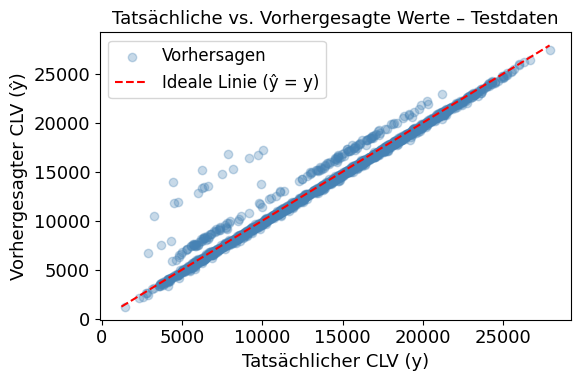

In [7]:
# Visualisierung: Tatsächliche vs. vorhergesagte Werte (Testdaten)
plt.figure(figsize=(6, 4))
plt.scatter(y_test, predictions_test, alpha=0.3, color='steelblue', label='Vorhersagen')

# Ideallinie: perfekte Vorhersage (ŷ = y)
min_val = min(y_test.min(), predictions_test.min())
max_val = max(y_test.max(), predictions_test.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideale Linie (ŷ = y)')

plt.xlabel('Tatsächlicher CLV (y)')
plt.ylabel('Vorhergesagter CLV (ŷ)')
plt.title('Tatsächliche vs. Vorhergesagte Werte – Testdaten')
plt.legend()
plt.tight_layout()
plt.show()

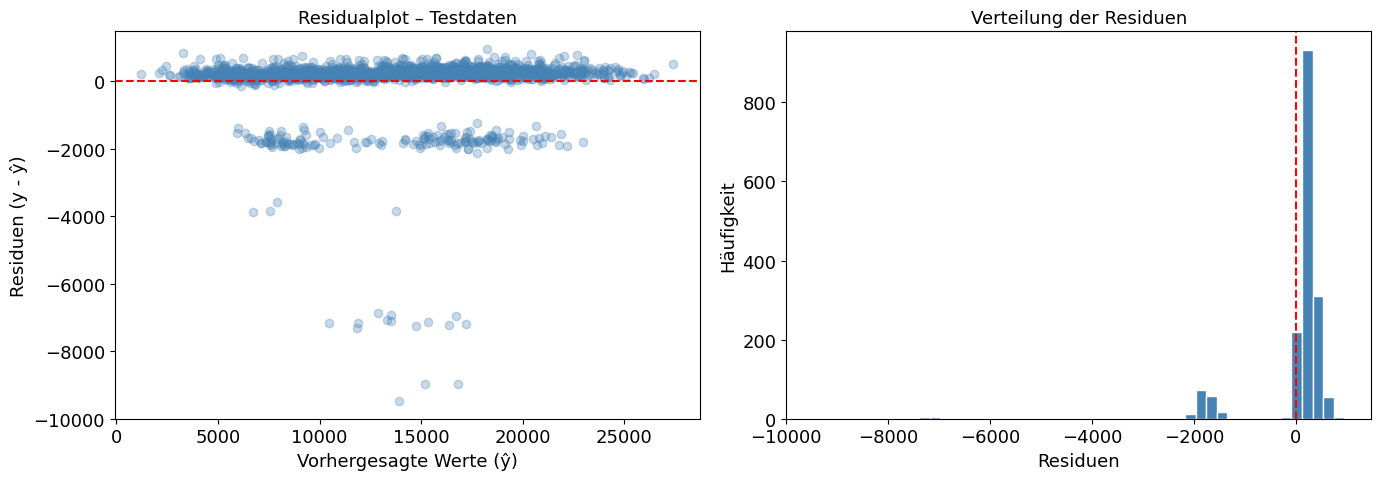

In [8]:
# Residualplot (Testdaten)
residuals = y_test - predictions_test

# Subplots definieren
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linkes Bild: Residuen vs. Vorhersagen
axes[0].scatter(predictions_test, residuals, alpha=0.3, color='steelblue')
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_xlabel('Vorhergesagte Werte (ŷ)')
axes[0].set_ylabel('Residuen (y - ŷ)')
axes[0].set_title('Residualplot – Testdaten')

# Rechtes Bild: Verteilung der Residuen (Histogramm)
axes[1].hist(residuals, bins=50, color='steelblue', edgecolor='white')
axes[1].axvline(x=0, color='red', linestyle='--')
axes[1].set_xlabel('Residuen')
axes[1].set_ylabel('Häufigkeit')
axes[1].set_title('Verteilung der Residuen')

plt.tight_layout()
plt.show()

Der Residualplot zeigt kein zufälliges Streumuster, sondern **deutliche horizontale Bänder** – insbesondere ein auffälliges Band bei ca. −2.000 €. Das ist ein Hinweis darauf, dass die Zielvariable `CLV_Continuous` vermutlich aus einer Berechnungsformel stammt, die diskrete Sprünge enthält (z. B. durch binäre Features wie `CIsActiveMember` oder `CHasCrCard`). Das lineare Modell kann diese Sprünge nicht exakt abbilden und "verfehlt" systematisch bestimmte Subgruppen.

Das Histogramm der Residuen zeigt eine Häufung nahe 0 mit einer deutlichen Linksschiefe – es gibt einige stark negative Ausreißer (bis −10.000 €), aber kaum positive Ausreißer gleicher Größe. Das deutet darauf hin, dass das Modell den CLV für bestimmte Kundengruppen systematisch **überschätzt**.

Trotz dieser Muster: Der größte Teil der Residuen liegt in einem schmalen Band um 0, was die ordentliche Gesamtperformance (R² ≈ 0,97) erklärt. Die Bänder deuten allerdings darauf hin, dass nichtlineare Modelle oder Interaktionsterme (wie in Task 3) hier helfen könnten.

---
## Task 3: Polynomiale Regression

**Ziel:** Mindestens zwei polynomiale Regressionsmodelle mit unterschiedlichen Polynomgraden trainieren und evaluieren. Anschließend erfolgt der Vergleich mit dem linearen Regressionsmodell aus Task 2.

**Ansatz & Motivation:**
**Polynomial Regression** erweitert das lineare Modell, indem Potenzen der vorhandenen Features als neue Features hinzugefügt werden. Damit können **nichtlineare Zusammenhänge** zwischen Features und Zielvariable modelliert werden – das zugrundeliegende Modell bleibt aber eine lineare Regression.

Das Modell für Grad $d$ lautet:

$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_1^2 + \ldots + \beta_d x_1^d + \ldots$$

**Gewählte Grade: 2 und 3**
- **Grad 2** fügt quadratische Terme und Interaktionen hinzu → moderate Erweiterung
- **Grad 3** fügt zusätzlich kubische Terme hinzu → mehr Flexibilität, aber auch mehr Overfitting-Risiko
- **Höhere Grade** (z.B. 10) dienen nur der Veranschaulichung von Overfitting über Lernkurven

> **PolynomialFeatures:** Ein sklearn-Transformer, der aus $n$ Original-Features alle Potenzen bis Grad $d$ sowie alle Kreuzterme (Interaktionen) erzeugt. Beispiel: aus Features $a, b$ mit $d=2$ entstehen: $a, b, a^2, ab, b^2$.

> **`include_bias=False`:** Unterdrückt den Bias-Term (Spalte aus Einsen), da `LinearRegression` den Intercept separat schätzt.

### 3.1: Polynomial Regression – Grad 2

**Polynomiale Features erzeugen (Grad 2)**
- Bei **22** Ausgangsfeatures erzeugt `PolynomialFeatures(degree=2, include_bias=False)` insgesamt

$$\binom{n+2}{2}-1 = \binom{24}{2}-1 = 276-1 = 275$$

Features. 
- Das Modell bleibt weiterhin linear in den Parametern ($\beta$), aber durch quadratische und Interaktionsterme kann es nichtlineare Zusammenhänge in den Daten abbilden.

In [9]:
# PolynomialFeatures: Grad 2 – erzeugt quadratische Terme und Interaktionen
poly_2 = PolynomialFeatures(degree=2, include_bias=False)
X_poly_2 = poly_2.fit_transform(X)

print(f"Features vor Transformation:  {X.shape[1]}")
print(f"Features nach Transformation: {X_poly_2.shape[1]}")

Features vor Transformation:  22
Features nach Transformation: 275


> **Hinweis Best Practice – `fit_transform` vor dem Train-Test-Split:**
> Hier wird `PolynomialFeatures.fit_transform()` auf dem *gesamten* Datensatz `X` aufgerufen, bevor gesplittet wird. Bei `PolynomialFeatures` entsteht dadurch kein echtes **Data Leakage** (= unbeabsichtigter Informationsfluss vom Test- in den Trainingsset), da der Transformer keine Statistiken aus den Daten lernt – er kombiniert Features rein mathematisch (Potenzen, Kreuzterme) ohne Parameter zu schätzen.
>
> Dennoch verstößt dieses Vorgehen gegen die **Best Practice** im Machine Learning: Der korrekte Ansatz ist, alle Transformationsschritte *innerhalb* einer Pipeline zu kapseln und erst auf den Trainingsdaten zu fitten:
>
> ```python
> # Best Practice: Pipeline-Ansatz (wie in Task 5 für Ridge/Lasso verwendet)
> pipeline = make_pipeline(PolynomialFeatures(degree=2, include_bias=False), LinearRegression())
> pipeline.fit(X_train, y_train)
> ```
>
> In Task 5 (Ridge- und Lasso-Regularisierung) wird dieser korrekte Pipeline-Ansatz konsequent umgesetzt. Der hier verwendete direkte Split hat auf die Metriken *keinen* numerischen Einfluss, ist aber aus Sicht der Code-Qualität und Reproduzierbarkeit dem Pipeline-Ansatz unterlegen.

### Train-Test-Split (Grad 2)

In [10]:
# X_poly_2 und y in Trainings- und Testdaten aufteilen
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X_poly_2, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)

print(f"Trainingsdaten:  {X_train_2.shape[0]} Zeilen, {X_train_2.shape[1]} Spalten")
print(f"Testdaten:       {X_test_2.shape[0]} Zeilen, {X_test_2.shape[1]} Spalten")

Trainingsdaten:  6816 Zeilen, 275 Spalten
Testdaten:       1705 Zeilen, 275 Spalten


### Modell trainieren (Grad 2)

In [11]:
# Lineares Regressionsmodell auf polynomialen Features erstellen und trainieren
lin_reg_poly_2 = LinearRegression()
lin_reg_poly_2.fit(X_train_2, y_train_2)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### Auswertung – Trainingsdaten (Grad 2)

In [12]:
# Vorhersagen auf Trainingsdaten
predictions_train_poly_2 = lin_reg_poly_2.predict(X_train_2)

# Mittleren absoluten Fehler berechnen
print('Mean Absolute Error (MAE):', mean_absolute_error(y_train_2, predictions_train_poly_2))
# Mittleren quadratischen Fehler berechnen
print('Mean Squared Error (MSE):', mean_squared_error(y_train_2, predictions_train_poly_2))
# Wurzel des mittleren quadratischen Fehlers berechnen
print('Root Mean Squared Error (RMSE):', np.sqrt(mean_squared_error(y_train_2, predictions_train_poly_2)))
# R²-Score berechnen
print('R²-Score:', r2_score(y_train_2, predictions_train_poly_2))

Mean Absolute Error (MAE): 456.1839698076956
Mean Squared Error (MSE): 751116.2193188475
Root Mean Squared Error (RMSE): 866.6696137045809
R²-Score: 0.9746720585462926


### Auswertung – Testdaten (Grad 2)

In [13]:
# Vorhersagen auf Testdaten
predictions_test_poly_2 = lin_reg_poly_2.predict(X_test_2)

# Mittleren absoluten Fehler berechnen
print('Mean Absolute Error (MAE):', mean_absolute_error(y_test_2, predictions_test_poly_2))
# Mittleren quadratischen Fehler berechnen
print('Mean Squared Error (MSE):', mean_squared_error(y_test_2, predictions_test_poly_2))
# Wurzel des mittleren quadratischen Fehlers berechnen
print('Root Mean Squared Error (RMSE):', np.sqrt(mean_squared_error(y_test_2, predictions_test_poly_2)))
# R²-Score berechnen
print('R²-Score:', r2_score(y_test_2, predictions_test_poly_2))

Mean Absolute Error (MAE): 487.03770735848644
Mean Squared Error (MSE): 864828.8162851918
Root Mean Squared Error (RMSE): 929.9617283981055
R²-Score: 0.9709702152856364


Der Test-RMSE verbessert sich von 948 € auf 930 € – eine Verbesserung von ~18 €, die eigentlich klein klingt, aber konsistent ist. Der Train-Test-Gap bleibt gering (Δ R² = 0,0037), das Modell generalisiert also stabil. Die quadratischen Terme und Interaktionseffekte scheinen also echte, wenn auch kleine nichtlineare Muster zu erfassen. Für Grad 3 würde ich jetzt mehr Overfitting erwarten.

## 3.2: Polynomial Regression – Grad 3

**Polynomiale Features erzeugen (Grad 3)**

In [14]:
# PolynomialFeatures: Grad 3 – erzeugt quadratische, kubische Terme und alle Interaktionen
poly_3 = PolynomialFeatures(degree=3, include_bias=False)
X_poly_3 = poly_3.fit_transform(X)

print(f"Features vor Transformation:  {X.shape[1]}")
print(f"Features nach Transformation: {X_poly_3.shape[1]}")

Features vor Transformation:  22
Features nach Transformation: 2299


### Train-Test-Split (Grad 3)

In [15]:
# X_poly_3 und y in Trainings- und Testdaten aufteilen
X_train_3, X_test_3, y_train_3, y_test_3 = train_test_split(X_poly_3, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)

print(f"Trainingsdaten:  {X_train_3.shape[0]} Zeilen")
print(f"Testdaten:       {X_test_3.shape[0]} Zeilen")

Trainingsdaten:  6816 Zeilen
Testdaten:       1705 Zeilen


### Modell trainieren (Grad 3)

In [16]:
# Lineares Regressionsmodell auf polynomialen Features erstellen und trainieren
lin_reg_poly_3 = LinearRegression()
lin_reg_poly_3.fit(X_train_3, y_train_3)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### Auswertung – Trainingsdaten (Grad 3)

In [17]:
# Vorhersagen auf Trainingsdaten
predictions_train_poly_3 = lin_reg_poly_3.predict(X_train_3)

# Mittleren absoluten Fehler berechnen
print('Mean Absolute Error (MAE):', mean_absolute_error(y_train_3, predictions_train_poly_3))
# Mittleren quadratischen Fehler berechnen
print('Mean Squared Error (MSE):', mean_squared_error(y_train_3, predictions_train_poly_3))
# Wurzel des mittleren quadratischen Fehlers berechnen
print('Root Mean Squared Error (RMSE):', np.sqrt(mean_squared_error(y_train_3, predictions_train_poly_3)))
# R²-Score berechnen
print('R²-Score:', r2_score(y_train_3, predictions_train_poly_3))

Mean Absolute Error (MAE): 477.3939104380955
Mean Squared Error (MSE): 732790.4469665099
Root Mean Squared Error (RMSE): 856.0318025438715
R²-Score: 0.9752900109713579


### Auswertung – Testdaten (Grad 3)

In [18]:
# Vorhersagen auf Testdaten
predictions_test_poly_3 = lin_reg_poly_3.predict(X_test_3)

# Mittleren absoluten Fehler berechnen
print('Mean Absolute Error (MAE):', mean_absolute_error(y_test_3, predictions_test_poly_3))
# Mittleren quadratischen Fehler berechnen
print('Mean Squared Error (MSE):', mean_squared_error(y_test_3, predictions_test_poly_3))
# Wurzel des mittleren quadratischen Fehlers berechnen
print('Root Mean Squared Error (RMSE):', np.sqrt(mean_squared_error(y_test_3, predictions_test_poly_3)))
# R²-Score berechnen
print('R²-Score:', r2_score(y_test_3, predictions_test_poly_3))

Mean Absolute Error (MAE): 525.5312846850863
Mean Squared Error (MSE): 892007.8571966027
Root Mean Squared Error (RMSE): 944.4616758749943
R²-Score: 0.9700578940359927


Wie erwartet: Train-RMSE sinkt weiter (856 € vs. 867 € bei Grad 2), aber der Test-RMSE steigt wieder an (944 € vs. 930 €). Das ist das klassische Overfitting-Zeichen – mit 2.299 Features passt sich das Modell zu stark an die Trainingsdaten an und verliert an Generalisierungsfähigkeit. Grad 2 war also der Sweet Spot.

### 3.3 Vergleichstabelle: Baseline vs. Grad 2 vs. Grad 3

In [19]:
# ---- Baseline (Grad 1) aus Task 2 neu berechnen für direkten Vergleich ----
X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)
lin_reg_1 = LinearRegression()
lin_reg_1.fit(X_train_1, y_train_1)
pred_train_1 = lin_reg_1.predict(X_train_1)
pred_test_1  = lin_reg_1.predict(X_test_1)

# ---- Zusammenfassende Tabelle ----
def metrics(y_true, y_pred):
    return {
        'MAE':  round(mean_absolute_error(y_true, y_pred), 2),
        'RMSE': round(np.sqrt(mean_squared_error(y_true, y_pred)), 2),
        'R²':   round(r2_score(y_true, y_pred), 4)
    }

comparison = pd.DataFrame({
    'Modell':         ['Grad 1 (Linear)', 'Grad 2 (Poly)', 'Grad 3 (Poly)'],
    'MAE Train':      [metrics(y_train_1, pred_train_1)['MAE'],
                       metrics(y_train_2, predictions_train_poly_2)['MAE'],
                       metrics(y_train_3, predictions_train_poly_3)['MAE']],
    'MAE Test':       [metrics(y_test_1, pred_test_1)['MAE'],
                       metrics(y_test_2, predictions_test_poly_2)['MAE'],
                       metrics(y_test_3, predictions_test_poly_3)['MAE']],
    'RMSE Train':     [metrics(y_train_1, pred_train_1)['RMSE'],
                       metrics(y_train_2, predictions_train_poly_2)['RMSE'],
                       metrics(y_train_3, predictions_train_poly_3)['RMSE']],
    'RMSE Test':      [metrics(y_test_1, pred_test_1)['RMSE'],
                       metrics(y_test_2, predictions_test_poly_2)['RMSE'],
                       metrics(y_test_3, predictions_test_poly_3)['RMSE']],
    'R² Train':       [metrics(y_train_1, pred_train_1)['R²'],
                       metrics(y_train_2, predictions_train_poly_2)['R²'],
                       metrics(y_train_3, predictions_train_poly_3)['R²']],
    'R² Test':        [metrics(y_test_1, pred_test_1)['R²'],
                       metrics(y_test_2, predictions_test_poly_2)['R²'],
                       metrics(y_test_3, predictions_test_poly_3)['R²']],
    'Anzahl Features':[X.shape[1], X_poly_2.shape[1], X_poly_3.shape[1]]
})

df_results = pd.DataFrame(comparison).set_index('Modell')
pd.set_option('display.float_format', '{:.4f}'.format)
df_results

,MAE Train,MAE Test,RMSE Train,RMSE Test,R² Train,R² Test,Anzahl Features
Modell,,,,,,,
Grad 1 (Linear),447.1500,465.7200,904.7300,947.9900,0.9724,0.9698,22
Grad 2 (Poly),456.1800,487.0400,866.6700,929.9600,0.9747,0.9710,275
Grad 3 (Poly),477.3900,525.5300,856.0300,944.4600,0.9753,0.9701,2299


### Lernkurven – Grad 1, 2, 3 und 10

Die Lernkurven werden auf demselben Feature-Set wie die eigentlichen Modelle in Sektion 4–6 berechnet (**alle 22 Features**, `X` und `y`), damit die RMSE-Werte direkt vergleichbar sind.

**Grad 10 (Overfitting-Illustration):** Ein polynomiales Modell mit Grad 10 auf 22 Features würde mehrere Millionen Features erzeugen und ist rechnerisch nicht handhabbar. Für dieses Modell werden daher die drei wichtigsten Features (`CBalance`, `CEstimatedSalary`, `CNumOfProducts`) verwendet. Die Kurve dient **ausschließlich der qualitativen Overfitting-Illustration** und ist nicht direkt mit den RMSE-Werten der anderen Modelle vergleichbar.

Alle Kurven starten bei 10 % Trainingsgröße und verwenden den Median über 5 KFold-Splits (`shuffle=True, random_state=42`).

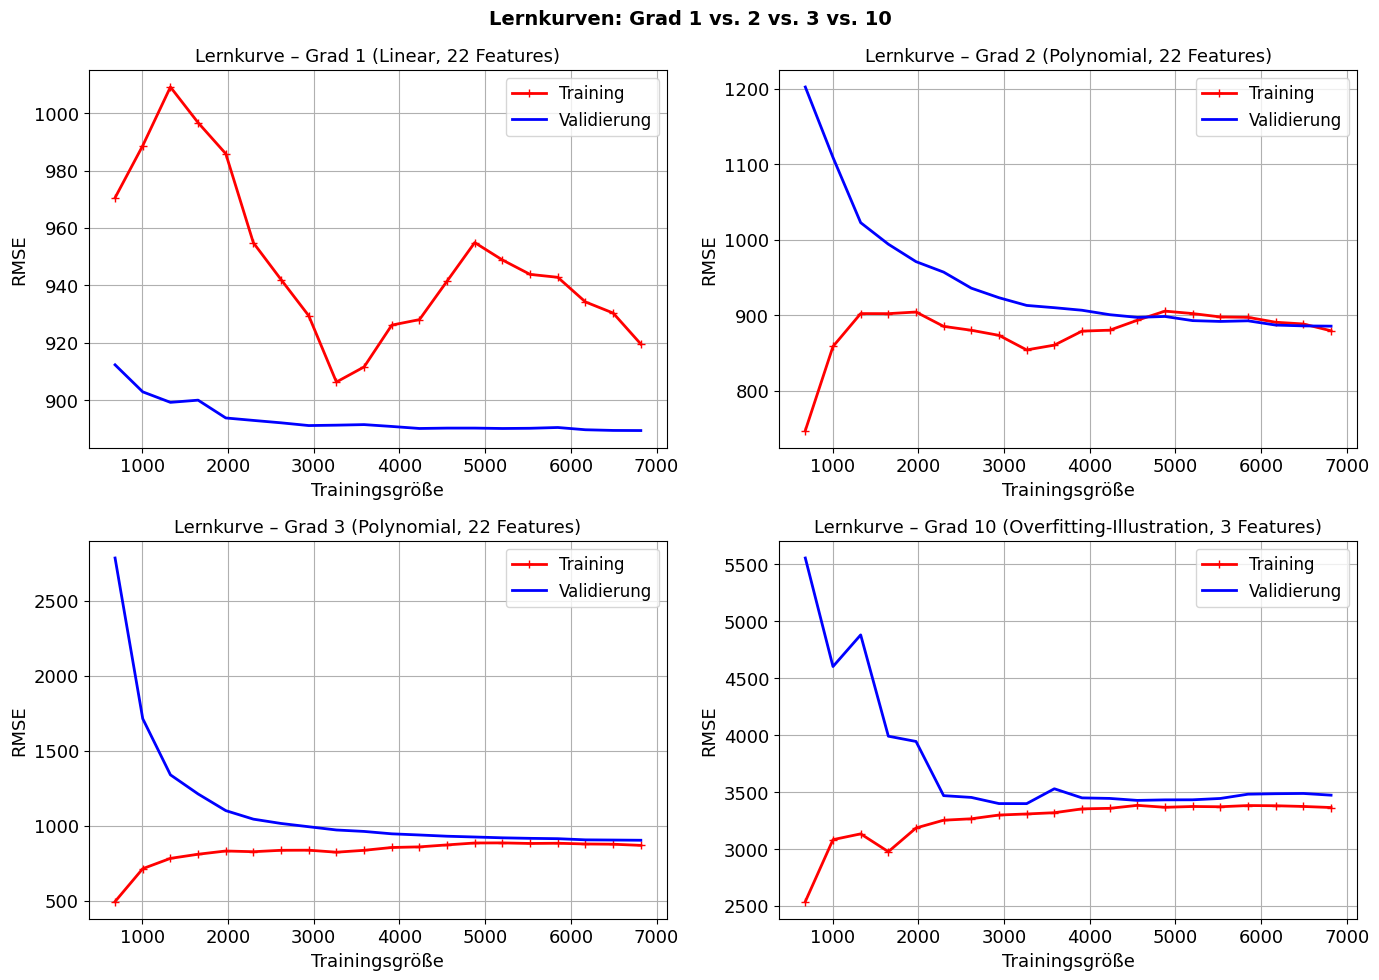

In [20]:
# Reproduzierbare, gemischte Folds für stabilere Lernkurven
cv_strategy = KFold(n_splits=K_FOLD_SPLITS, shuffle=True, random_state=RANDOM_STATE)

def compute_learning_curve_rmse(model, X_data, y_data, train_sizes, cv):
    train_sizes_abs, train_scores, valid_scores = learning_curve(
        model,
        X_data,
        y_data,
        train_sizes=train_sizes,
        cv=cv,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    )
    # Robustere Aggregation über Folds: Median statt Mittelwert
    train_rmse = -np.median(train_scores, axis=1)
    valid_rmse = -np.median(valid_scores, axis=1)
    return train_sizes_abs, train_rmse, valid_rmse

train_sizes = np.linspace(0.1, 1.0, 20)  # Start bei 10 % (0.0 ist ungültig)

# Modelle für die Lernkurven
model_1 = LinearRegression(n_jobs=-1)
model_2 = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    LinearRegression(n_jobs=-1)
)
model_3 = make_pipeline(
    PolynomialFeatures(degree=3, include_bias=False),
    LinearRegression(n_jobs=-1)
)
model_10 = make_pipeline(
    PolynomialFeatures(degree=10, include_bias=False),
    LinearRegression(n_jobs=-1)
)

# Grad 1, 2, 3: alle 22 Features – identisch zu den Modellen in Sektion 4–6
X_lc_full = X.values
y_lc_full = y.values

# Grad 10: nur 3 Features (Overfitting-Illustration, rechnerisch begrenzt)
X_lc_3 = df[['CBalance', 'CEstimatedSalary', 'CNumOfProducts']].values
y_lc_3  = y.values

# Lernkurven berechnen
sizes_1,  train_1,  valid_1  = compute_learning_curve_rmse(model_1,  X_lc_full, y_lc_full, train_sizes, cv_strategy)
sizes_2,  train_2,  valid_2  = compute_learning_curve_rmse(model_2,  X_lc_full, y_lc_full, train_sizes, cv_strategy)
sizes_3,  train_3,  valid_3  = compute_learning_curve_rmse(model_3,  X_lc_full, y_lc_full, train_sizes, cv_strategy)
sizes_10, train_10, valid_10 = compute_learning_curve_rmse(model_10, X_lc_3,    y_lc_3,    train_sizes, cv_strategy)

# 2×2 Plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

curves = [
    (sizes_1,  train_1,  valid_1,  'Grad 1 (Linear, 22 Features)'),
    (sizes_2,  train_2,  valid_2,  'Grad 2 (Polynomial, 22 Features)'),
    (sizes_3,  train_3,  valid_3,  'Grad 3 (Polynomial, 22 Features)'),
    (sizes_10, train_10, valid_10, 'Grad 10 (Overfitting-Illustration, 3 Features)'),
]

for ax, (sizes, train_err, valid_err, title) in zip(axes, curves):
    ax.plot(sizes, train_err, 'r-+', linewidth=2, label='Training')
    ax.plot(sizes, valid_err, 'b-',  linewidth=2, label='Validierung')
    ax.set_title(f'Lernkurve – {title}')
    ax.set_xlabel('Trainingsgröße')
    ax.set_ylabel('RMSE')
    ax.legend(loc='upper right')
    ax.grid(True)

plt.suptitle('Lernkurven: Grad 1 vs. 2 vs. 3 vs. 10', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3.4 Interpretation der Ergebnisse

### 3.4.1 Modellvergleich

| Modell | RMSE Test | R² Test | Anzahl Features |
|---|---|---|---|
| Grad 1 (Baseline) | 947,99 | 0,9698 | 22 |
| **Grad 2** | **929,96** | **0,9710** | 275 |
| Grad 3 | 944,46 | 0,9701 | 2.299 |

Grad 2 gewinnt knapp – niedrigster Test-RMSE, höchstes R² auf Testdaten. Das ist das erwartete Ergebnis, auch wenn der Unterschied klein ist.

### 3.4.2 Wie verändert sich die Performance mit steigendem Grad?

Von Grad 1 → Grad 2 gibt es eine kleine aber echte Verbesserung: Der RMSE sinkt um ~18 €. Von Grad 2 → Grad 3 verschlechtert sich das Testset-Ergebnis wieder. Das Muster ist klar: mehr Komplexität hilft bis zu einem gewissen Punkt, danach lernt das Modell nur noch Rauschen.

> **Overfitting** bedeutet hier: Das Modell hat bei Grad 3 mit 2.299 Features so viele Freiheitsgrade, dass es die Trainingsdaten zu genau abbildet – auf neuen Daten funktioniert das dann schlechter.

### 3.4.3 Lernkurve – Analyse

**Grad 1:** Beide Kurven liegen eng beieinander und sind stabil – kein Overfitting, aber das Modell erfasst nichtlineare Muster nicht vollständig. Bei kleinen Trainingsmengen schwankt die Trainingskurve stärker – das ist bei KFold-CV mit zufällig zusammengestellten Folds normal und kein Hinweis auf ein Modellproblem.

**Grad 2:** Bei kleinen Trainingsmengen gibt es zunächst deutliches Overfitting (Training ~740 RMSE vs. Validierung ~1.200 RMSE). Mit mehr Daten schließt sich der Gap – das Modell braucht also eine ausreichend große Datenbasis, funktioniert dann aber gut.

**Grad 3:** Der Gap zwischen Training und Validierung bleibt auch mit mehr Daten bestehen. Mehr Daten allein würden das Overfitting hier nicht lösen – das Modell ist strukturell zu komplex für diesen Datensatz.

**Grad 10 (Illustration):** Hier wird das Overfitting-Problem extrem deutlich. Rein zur Veranschaulichung – dieser Grad wäre für die eigentliche Aufgabe nicht einsetzbar.

---
# Task 4: Modellvergleich & Entscheidung

| Modell | RMSE Test | R² Test | Anzahl Features | Komplexität |
|---|---|---|---|---|
| Grad 1 – Multiple Linear Regression | 947,99 € | 0,9698 | 22 | Niedrig |
| **Grad 2 – Polynomial Regression** | **929,96 €** | **0,9710** | 275 | Mittel |
| Grad 3 – Polynomial Regression | 944,46 € | 0,9701 | 2.299 | Hoch |

### Entscheidung: Polynomial Regression Grad 2

Grad 2 gewinnt – bester Test-RMSE (929,96 €), höchstes Test-R² (0,9710) und kein Overfitting (Train/Test-Gap nur 0,0037). Der Unterschied zur linearen Regression ist mit ~18 € RMSE nicht riesig, aber Grad 2 erfasst echte nichtlineare Zusammenhänge effizienter als Grad 3 mit fast zehnmal so vielen Features.

Grad 3 bringt keinen Mehrwert – höhere Komplexität ohne bessere Testperformance ist bei Regressionsmodellen generell ein Warnsignal. Das lineare Modell ist zwar eine solide Baseline, kann aber die nichtlinearen Zusammenhänge im Datensatz nicht vollständig erfassen.

**→ Grad 2 geht in Task 5 als Ausgangsmodell für die Regularisierung.**

---
# Task 5: Regularisierung & Optimierung

**Ausgangspunkt:** Polynomial Regression Grad 2 (bestes Modell aus Task 3/4)  
**Ziel:** Optimierung durch Ridge- und Lasso-Regularisierung mit GridSearchCV und Cross-Validation

**Vorgehen:**
1. Beide Regularisierungsmethoden (Ridge & Lasso) mit Pipeline
2. Hyperparameter-Tuning mit `GridSearchCV`
3. Evaluation mit 5-facher Cross-Validation
4. Overfitting/Underfitting analysieren
5. Vergleich mit unregulärisiertem Modell aus Task 3

**Ansatz & Motivation**

**Warum Regularisierung?**  
Das Polynomial-Regressionsmodell (Grad 2) erzeugt 275 Features – darunter viele Kreuzterme und quadratische Terme, die möglicherweise kein echtes Signal tragen. Ohne Regularisierung besteht das Risiko, dass das Modell zu viel Gewicht auf irrelevante Features legt.

**Ridge Regression (L2):**  
Fügt der Kostenfunktion einen Strafterm hinzu, der die Summe der **quadrierten** Koeffizienten minimiert. Alle Koeffizienten werden kleiner, aber keiner wird exakt 0.
$$\text{Kostenfunktion} = \text{MSE} + \alpha \sum_{i=1}^{n} \beta_i^2$$

**Lasso Regression (L1):**  
Minimiert die Summe der **absoluten** Koeffizienten. Lasso kann Koeffizienten exakt auf 0 setzen → **automatische Feature-Selektion**.
$$\text{Kostenfunktion} = \text{MSE} + \alpha \sum_{i=1}^{n} |\beta_i|$$

> **Hyperparameter α:** Steuert die Stärke der Regularisierung. α = 0 entspricht normaler linearer Regression. Je größer α, desto stärker werden die Koeffizienten bestraft.

> **StandardScaler:** Regularisierung ist skalierungssensitiv – Features mit großen Werten würden sonst stärker bestraft. Deshalb werden alle Features vor der Regularisierung auf Mittelwert 0 und Standardabweichung 1 skaliert.

> **Cross-Validation (CV):** Das Modell wird k-mal auf verschiedenen Train/Validierungs-Splits trainiert und evaluiert. Der Mittelwert der Fehler gibt eine robustere Schätzung der Generalisierungsfähigkeit als ein einziger Split.

> **GridSearchCV:** Testet systematisch alle Kombinationen aus einem vorgegebenen Hyperparameter-Raster und wählt die Kombination mit dem besten CV-Score.

**Hinweis:** Feature-Matrix `X`, Zielvariable `y` sowie `X_train`, `X_test`, `y_train`, `y_test` wurden im Setup-Abschnitt definiert und stehen hier direkt zur Verfügung. Ein erneuter Train-Test-Split ist nicht notwendig.

### 5.1 Ridge Regression – Hyperparameter-Tuning mit GridSearchCV

In [21]:
# Pipeline: PolynomialFeatures → StandardScaler → Ridge
ridge_pipeline = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    StandardScaler(), # bei Regularisierung erforderlich (skalierungssensitiv)
    Ridge(solver='cholesky')
)

# Hyperparameter fuer Alpha
param_grid_ridge = {'ridge__alpha': [0.01, 0.1, 1.0, 10.0, 100.0, 500.0, 1000.0]}

# GridSearchCV mit 5-facher Cross-Validation
grid_ridge = GridSearchCV(
    ridge_pipeline,
    param_grid_ridge,
    cv=KFold(n_splits=K_FOLD_SPLITS, shuffle=True, random_state=RANDOM_STATE),
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    refit=True
)
grid_ridge.fit(X_train, y_train)

# Ausgabe
print(f"Bestes Alpha (Ridge): {grid_ridge.best_params_}")
print(f"Bester CV-RMSE:       {-grid_ridge.best_score_:.4f}")

Bestes Alpha (Ridge): {'ridge__alpha': 1.0}
Bester CV-RMSE:       908.3319


In [22]:
# Alle Alpha-Werte und ihre CV-Ergebnisse
ridge_results = pd.DataFrame({
    'Alpha': grid_ridge.cv_results_['param_ridge__alpha'],
    'CV RMSE': -grid_ridge.cv_results_['mean_test_score']
})

# Ausgabe
print(ridge_results.to_string(index=False))

    Alpha   CV RMSE
   0.0100  908.5313
   0.1000  908.5014
   1.0000  908.3319
  10.0000  911.7251
 100.0000  942.0363
 500.0000  984.4268
1000.0000 1010.7041


Die Alpha-Werte von 0,01 bis 1,0 liefern nahezu identische CV-RMSE-Werte (~908 €). Das zeigt, dass bei diesem Datensatz nur minimale Regularisierung nötig ist – das unregularisierte Poly-Grad-2-Modell overfittet kaum. Ab α = 10 steigt der Fehler merklich, da zu starke Bestrafung die Koeffizienten unnötig einschränkt und Vorhersagekraft verloren geht.

### Auswertung – bestes Ridge-Modell

In [23]:
best_ridge = grid_ridge.best_estimator_

# Vorhersagen auf Trainingsdaten
predictions_train_ridge = best_ridge.predict(X_train)
print('=== Ridge - Trainingsdaten ===')
print('Mean Absolute Error (MAE):', mean_absolute_error(y_train, predictions_train_ridge))
print('Mean Squared Error (MSE):', mean_squared_error(y_train, predictions_train_ridge))
print('Root Mean Squared Error (RMSE):', np.sqrt(mean_squared_error(y_train, predictions_train_ridge)))
print('R2-Score:', r2_score(y_train, predictions_train_ridge))

=== Ridge - Trainingsdaten ===
Mean Absolute Error (MAE): 456.44842715942116
Mean Squared Error (MSE): 751250.4417197692
Root Mean Squared Error (RMSE): 866.7470459827188
R2-Score: 0.9746675325128707


In [24]:
# Vorhersagen auf Testdaten
predictions_test_ridge = best_ridge.predict(X_test)
print('=== Ridge - Testdaten ===')
print('Mean Absolute Error (MAE):', mean_absolute_error(y_test, predictions_test_ridge))
print('Mean Squared Error (MSE):', mean_squared_error(y_test, predictions_test_ridge))
print('Root Mean Squared Error (RMSE):', np.sqrt(mean_squared_error(y_test, predictions_test_ridge)))
print('R2-Score:', r2_score(y_test, predictions_test_ridge))

=== Ridge - Testdaten ===
Mean Absolute Error (MAE): 486.94976190061084
Mean Squared Error (MSE): 864380.6805580654
Root Mean Squared Error (RMSE): 929.7207540751499
R2-Score: 0.9709852578968866


In [25]:
# 5-fache Cross-Validation auf dem besten Ridge-Modell
cv_scores_ridge = cross_val_score(
    best_ridge, X_train, y_train,
    cv=KFold(n_splits=K_FOLD_SPLITS, shuffle=True, random_state=RANDOM_STATE),
    scoring='neg_root_mean_squared_error'
)
print(f"CV RMSE (5-fold): {-cv_scores_ridge.mean():.4f} +/- {cv_scores_ridge.std():.4f}")

CV RMSE (5-fold): 908.3319 +/- 18.0165


### 5.2 Lasso Regression – Hyperparameter-Tuning mit GridSearchCV

In [26]:
# Pipeline: PolynomialFeatures → StandardScaler → Lasso
lasso_pipeline = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    StandardScaler(),
    Lasso(max_iter=50000)
)

# Hyperparameter fuer Alpha
# Suchraum bewusst symmetrisch zu Ridge (ab 0.01) gewählt, um den gesamten
# relevanten Bereich abzudecken und das Optimum nicht zu verfehlen.
param_grid_lasso = {'lasso__alpha': [0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0]}

# GridSearchCV mit 5-facher Cross-Validation
grid_lasso = GridSearchCV(
    lasso_pipeline,
    param_grid_lasso,
    cv=KFold(n_splits=K_FOLD_SPLITS, shuffle=True, random_state=RANDOM_STATE),
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    refit=True
)
grid_lasso.fit(X_train, y_train)

# Ausgabe
print(f"Bestes Alpha (Lasso): {grid_lasso.best_params_}")
print(f"Bester CV-RMSE:       {-grid_lasso.best_score_:.4f}")

Bestes Alpha (Lasso): {'lasso__alpha': 10.0}
Bester CV-RMSE:       892.8542


In [27]:
# Alle Alpha-Werte und ihre CV-Ergebnisse
lasso_results = pd.DataFrame({
    'Alpha': grid_lasso.cv_results_['param_lasso__alpha'],
    'CV RMSE': -grid_lasso.cv_results_['mean_test_score']
})

# Ausgabe
print(lasso_results.to_string(index=False))

   Alpha  CV RMSE
  0.0100 908.3951
  0.1000 907.1996
  0.5000 903.3721
  1.0000 900.7863
  5.0000 893.2421
 10.0000 892.8542
 50.0000 916.3172
100.0000 960.5560


Das Optimum liegt bei α = 10 (CV-RMSE 892,85 €). Was mich hier überrascht hat: Ein so großes α bedeutet, dass Lasso 219 von 275 Features auf exakt 0 setzt – das Modell arbeitet also mit nur 56 aktiven Features. Dass das zu einem besseren CV-RMSE führt als das unregulärisierte Modell, zeigt deutlich, wie viele der 275 polynomialen Features einfach Rauschen tragen. Kleinere Alpha-Werte (1–5) liegen nur knapp darüber, größere (≥50) verschlechtern die Performance erheblich – zu aggressive Elimination entfernt auch relevante Features.

### Auswertung – bestes Lasso-Modell

In [28]:
best_lasso = grid_lasso.best_estimator_

# Vorhersagen auf Trainingsdaten
predictions_train_lasso = best_lasso.predict(X_train)
print('=== Lasso - Trainingsdaten ===')
print('Mean Absolute Error (MAE):', mean_absolute_error(y_train, predictions_train_lasso))
print('Mean Squared Error (MSE):', mean_squared_error(y_train, predictions_train_lasso))
print('Root Mean Squared Error (RMSE):', np.sqrt(mean_squared_error(y_train, predictions_train_lasso)))
print('R2-Score:', r2_score(y_train, predictions_train_lasso))

=== Lasso - Trainingsdaten ===
Mean Absolute Error (MAE): 451.16984857657246
Mean Squared Error (MSE): 781873.8218424177
Root Mean Squared Error (RMSE): 884.236292990973
R2-Score: 0.9736348998004998


In [29]:
# Vorhersagen auf Testdaten
predictions_test_lasso = best_lasso.predict(X_test)
print('=== Lasso - Testdaten ===')
print('Mean Absolute Error (MAE):', mean_absolute_error(y_test, predictions_test_lasso))
print('Mean Squared Error (MSE):', mean_squared_error(y_test, predictions_test_lasso))
print('Root Mean Squared Error (RMSE):', np.sqrt(mean_squared_error(y_test, predictions_test_lasso)))
print('R2-Score:', r2_score(y_test, predictions_test_lasso))

=== Lasso - Testdaten ===
Mean Absolute Error (MAE): 470.11108150683435
Mean Squared Error (MSE): 847777.0802223076
Root Mean Squared Error (RMSE): 920.7481089974107
R2-Score: 0.9715425924053512


In [30]:
# 5-fache Cross-Validation auf dem besten Lasso-Modell
# Hinweis: Gleiche CV-Strategie wie in GridSearchCV (shuffle=True) fuer Konsistenz
cv_scores_lasso = cross_val_score(
    best_lasso, X_train, y_train,
    cv=KFold(n_splits=K_FOLD_SPLITS, shuffle=True, random_state=RANDOM_STATE),
    scoring='neg_root_mean_squared_error'
)
print(f"CV RMSE (5-fold): {-cv_scores_lasso.mean():.4f} +/- {cv_scores_lasso.std():.4f}")

# Lasso Feature-Selektion: Wie viele Features wurden eliminiert?
lasso_coef = best_lasso.named_steps['lasso'].coef_
n_zero = (lasso_coef == 0).sum()
n_total = len(lasso_coef)
print(f"\nFeatures eliminiert (Koeffizient = 0): {n_zero} von {n_total} ({n_zero/n_total*100:.1f}%)")
print(f"Aktive Features: {n_total - n_zero}")

CV RMSE (5-fold): 892.8542 +/- 21.3782

Features eliminiert (Koeffizient = 0): 219 von 275 (79.6%)
Aktive Features: 56


### Visualisierung: Alpha vs. CV-RMSE

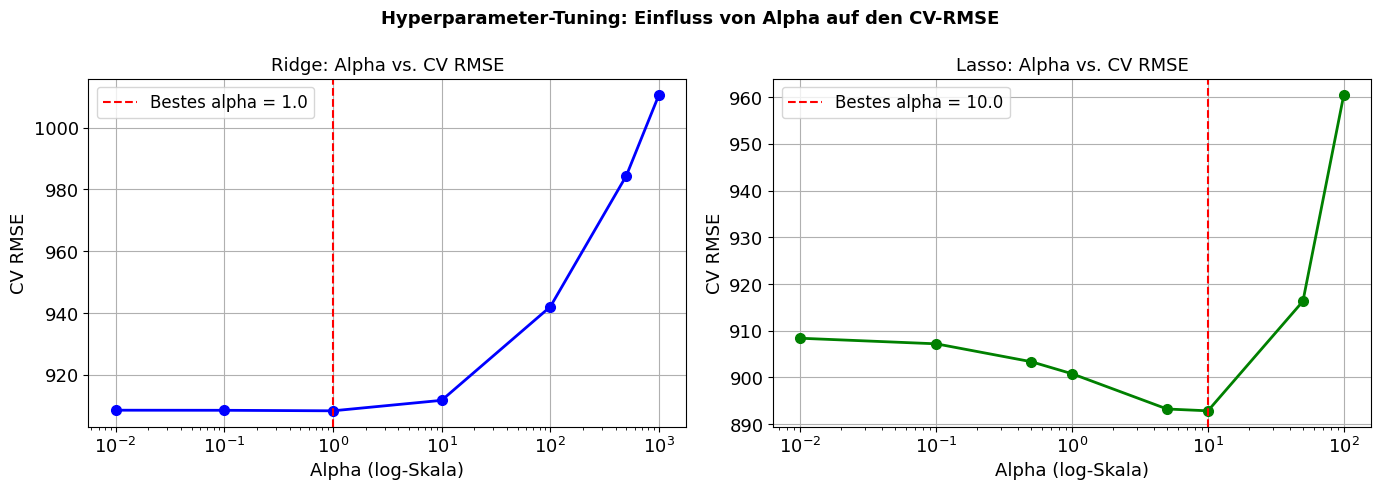

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ridge
ridge_alphas = [r['ridge__alpha'] for r in grid_ridge.cv_results_['params']]
ridge_cv_rmse = -grid_ridge.cv_results_['mean_test_score']
axes[0].plot(ridge_alphas, ridge_cv_rmse, 'bo-', linewidth=2, markersize=7)
axes[0].axvline(grid_ridge.best_params_['ridge__alpha'], color='red',
                linestyle='--', label=f"Bestes alpha = {grid_ridge.best_params_['ridge__alpha']}")
axes[0].set_xscale('log')
axes[0].set_xlabel('Alpha (log-Skala)')
axes[0].set_ylabel('CV RMSE')
axes[0].set_title('Ridge: Alpha vs. CV RMSE')
axes[0].legend()
axes[0].grid(True)

# Lasso
lasso_alphas = [r['lasso__alpha'] for r in grid_lasso.cv_results_['params']]
lasso_cv_rmse = -grid_lasso.cv_results_['mean_test_score']
axes[1].plot(lasso_alphas, lasso_cv_rmse, 'go-', linewidth=2, markersize=7)
axes[1].axvline(grid_lasso.best_params_['lasso__alpha'], color='red',
                linestyle='--', label=f"Bestes alpha = {grid_lasso.best_params_['lasso__alpha']}")
axes[1].set_xscale('log')
axes[1].set_xlabel('Alpha (log-Skala)')
axes[1].set_ylabel('CV RMSE')
axes[1].set_title('Lasso: Alpha vs. CV RMSE')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Hyperparameter-Tuning: Einfluss von Alpha auf den CV-RMSE', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Beide Kurven bestätigen die GridSearchCV-Ergebnisse visuell. **Ridge** (links) zeigt eine flache Kurve bei kleinen Alpha-Werten – das Modell reagiert wenig sensitiv auf schwache Regularisierung. **Lasso** (rechts) zeigt ein klareres Minimum bei α = 10, da die L1-Regularisierung durch Feature-Elimination einen stärkeren Effekt hat. In beiden Fällen verschlechtern zu hohe Alpha-Werte die Performance erheblich, da die Koeffizienten zu stark gegen Null gedrückt werden (Underfitting-Tendenz).

### 5.3 Gesamtvergleich: Unregulärisiert vs. Ridge vs. Lasso

In [32]:
# Zusammenfassende Vergleichstabelle
comparison = pd.DataFrame({
    'Modell': [
        'Poly Grad 2 (unreg.)',
        'Ridge (alpha=1.0)',
        'Lasso (alpha=10.0)'
    ],
    'RMSE Train': [
        866.67,
        round(np.sqrt(mean_squared_error(y_train, predictions_train_ridge)), 2),
        round(np.sqrt(mean_squared_error(y_train, predictions_train_lasso)), 2)
    ],
    'RMSE Test': [
        929.96,
        round(np.sqrt(mean_squared_error(y_test, predictions_test_ridge)), 2),
        round(np.sqrt(mean_squared_error(y_test, predictions_test_lasso)), 2)
    ],
    'R2 Train': [
        0.9747,
        round(r2_score(y_train, predictions_train_ridge), 4),
        round(r2_score(y_train, predictions_train_lasso), 4)
    ],
    'R2 Test': [
        0.9710,
        round(r2_score(y_test, predictions_test_ridge), 4),
        round(r2_score(y_test, predictions_test_lasso), 4)
    ],
    'CV RMSE': [
        '-',
        f"{-cv_scores_ridge.mean():.2f} +/- {cv_scores_ridge.std():.2f}",
        f"{-cv_scores_lasso.mean():.2f} +/- {cv_scores_lasso.std():.2f}"
    ]
})
print(comparison.to_string(index=False))

              Modell  RMSE Train  RMSE Test  R2 Train  R2 Test          CV RMSE
Poly Grad 2 (unreg.)    866.6700   929.9600    0.9747   0.9710                -
   Ridge (alpha=1.0)    866.7500   929.7200    0.9747   0.9710 908.33 +/- 18.02
  Lasso (alpha=10.0)    884.2400   920.7500    0.9736   0.9715 892.85 +/- 21.38


### Lernkurve optimiertes Lasso Modell

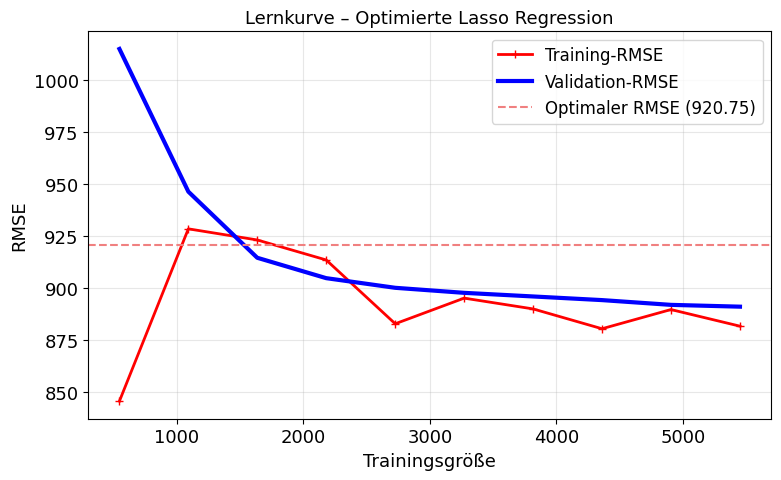

In [33]:
train_sizes, train_scores, valid_scores = learning_curve(
    best_lasso,
    X_train,
    y_train,
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

train_rmse_curve = -train_scores.mean(axis=1)
valid_rmse_curve = -valid_scores.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_rmse_curve, 'r-+', linewidth=2, label='Training-RMSE')
plt.plot(train_sizes, valid_rmse_curve, 'b-', linewidth=3, label='Validation-RMSE')
opt_rmse = round(np.sqrt(mean_squared_error(y_test, predictions_test_lasso)), 2)
plt.axhline(y=opt_rmse, color='lightcoral', linestyle='--', linewidth=1.5,
            label=f'Optimaler RMSE ({opt_rmse:.2f})')
plt.xlabel('Trainingsgröße')
plt.ylabel('RMSE')
plt.title('Lernkurve – Optimierte Lasso Regression')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Die Lernkurve sieht gut aus: Training- und Validierungskurve konvergieren eng, kein großer Gap. Der finale Validierungs-RMSE liegt nah am Test-RMSE (920,75 €) – das Modell generalisiert stabil. Zum Vergleich: Das unregulärisierte Poly-Grad-2-Modell hatte bei kleinen Trainingsmengen noch deutlich sichtbaren Gap – Lasso hat das behoben.

## 5.4 Interpretation der Ergebnisse

### 5.4.1 Modellvergleich

| Modell | RMSE Test | R² Test | CV RMSE |
|---|---|---|---|
| Poly Grad 2 (unreg.) | 929,96 € | 0,9710 | – |
| Ridge (α = 1,0) | 929,72 € | 0,9710 | 908,33 ± 18,02 |
| **Lasso (α = 10,0)** | **920,75 €** | **0,9715** | **892,85 ± 21,38** |

### 5.4.2 Overfitting / Underfitting

Weder Ridge noch Lasso zeigen Overfitting – Train/Test-Gap jeweils minimal. Lasso reduziert dabei 219 von 275 Features auf exakt 0, arbeitet also nur mit 56 aktiven Features. Das bestätigt: Ein Großteil der polynomialen Terme trägt kein echtes Signal.

### 5.4.3 Warum gewinnt Lasso?

Der CV-RMSE von Lasso (893 €) liegt ~15 € unter dem von Ridge (908 €). Bei 275 Features und ~8.500 Beobachtungen macht Feature-Selektion Sinn – viele Kreuzterme aus `PolynomialFeatures` sind redundant. Ridge verkleinert alle Koeffizienten gleichmäßig, eliminiert aber nichts; Lasso erkennt die redundanten Features und streicht sie.

### 5.4.4 Gewählte Hyperparameter

**Ridge α = 1,0:** Schwache Regularisierung reicht hier – das unregulärisierte Modell overfittet kaum, also braucht man keine starke Bestrafung. Größere Alpha-Werte verschlechtern den CV-RMSE deutlich.

**Lasso α = 10,0:** Moderat – eliminiert 79,6% der Features, ohne zu viel Vorhersagekraft zu verlieren. α = 1 hilft kaum, α ≥ 50 geht zu weit.

### 5.4.5 Fazit

**Lasso (Grad 2, α = 10)** ist das beste Modell aus Task 5: niedrigster Test-RMSE (920,75 €), bester CV-RMSE (892,85 €), kein Overfitting – und das mit nur 56 von 275 Features. Das ist ein schönes Ergebnis, weil das Modell dadurch auch deutlich interpretierbarer wird. Dieses Modell geht als Referenz in Task 7.

---
# Task 6: Regressionsbaum

**Ziel:** Training und Evaluation eines Regressionsbaums zur Vorhersage von `CLV_Continuous`, mit Hyperparameter-Tuning (GridSearchCV) und Cross-Validation.

**Ansatz & Motivation**
Ein **Regressionsbaum** (engl. Regression Tree) ist ein Entscheidungsbaum, der statt einer Klasse einen **kontinuierlichen Wert** vorhersagt. An jedem Knoten wird das Feature gewählt, das die Trainingsdaten am besten aufteilt. In den Blättern steht der **Mittelwert** aller Trainingsbeispiele, die diesen Knoten erreichen.

**Motivationen für diesen Datensatz:**
- Kein linearer Zusammenhang zwischen Features und CLV erforderlich
- Automatische Feature-Selektion durch das Splitting-Verfahren
- Kein StandardScaler nötig – Bäume sind skalierungsunabhängig
- Gut interpretierbar durch Feature Importances

**Wichtige Hyperparameter:**

> **`max_depth`:** Maximale Tiefe des Baums. Ohne Begrenzung wächst der Baum so lange, bis alle Blätter rein sind → starkes Overfitting.

> **`min_samples_leaf`:** Minimale Anzahl an Trainingsbeispielen in einem Blatt. Höhere Werte erzwingen allgemeinere Blätter und reduzieren Overfitting.

> **`min_samples_split`:** Minimale Anzahl an Beispielen, die ein Knoten haben muss, um weiter aufgeteilt zu werden.

### Trainieren und Testen

In [34]:
# Default DecisionTreeRegressor – keinerlei Regularisierung
tree_default = DecisionTreeRegressor(random_state=RANDOM_STATE)
tree_default.fit(X_train, y_train)

pred_train_default = tree_default.predict(X_train)
pred_test_default  = tree_default.predict(X_test)

### Auswertung

In [35]:
print('=== Default Tree – Trainingsdaten ===')
print('Root Mean Squared Error (RMSE):', np.sqrt(mean_squared_error(y_train, pred_train_default)))
print('R2-Score:', r2_score(y_train, pred_train_default))

print('\n=== Default Tree – Testdaten ===')
print('Root Mean Squared Error (RMSE):', np.sqrt(mean_squared_error(y_test, pred_test_default)))
print('R2-Score:', r2_score(y_test, pred_test_default))

print(f'\nBaumtiefe: {tree_default.get_depth()}')
print(f'Anzahl Blätter: {tree_default.get_n_leaves()}')

=== Default Tree – Trainingsdaten ===
Root Mean Squared Error (RMSE): 0.0
R2-Score: 1.0

=== Default Tree – Testdaten ===
Root Mean Squared Error (RMSE): 969.1376303444056
R2-Score: 0.9684728598692998

Baumtiefe: 23
Anzahl Blätter: 6789


Train-RMSE = 0, R² = 1,0 – der Baum hat die Trainingsdaten perfekt auswendig gelernt (Tiefe 23, 6.789 Blätter). Der Test-RMSE liegt trotzdem bei 969 € – schlechter als das lineare Baseline-Modell aus Task 2. Klassisches Overfitting: Was auf den Trainingsdaten perfekt funktioniert, generalisiert schlecht. Ohne Hyperparameter-Tuning ist ein Regressionsbaum hier nicht einsetzbar.

### Hyperparameter-Tuning mit GridSearchCV

In [36]:
# Hyperparameter-Raster
param_grid = {
    'max_depth':         [3, 5, 7, 10, 15, None],
    'min_samples_leaf':  [1, 5, 10, 20, 50],
    'min_samples_split': [2, 10, 20]
}

# GridSearchCV mit 5-facher Cross-Validation
tree_grid = GridSearchCV(
    DecisionTreeRegressor(random_state=RANDOM_STATE),
    param_grid,
    cv=KFold(n_splits=K_FOLD_SPLITS, shuffle=True, random_state=RANDOM_STATE),
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
tree_grid.fit(X_train, y_train)

print(f"Beste Parameter: {tree_grid.best_params_}")
print(f"Bester CV-RMSE:  {-tree_grid.best_score_:.4f}")

Beste Parameter: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 20}
Bester CV-RMSE:  992.1718


In [37]:
# Top 8 Parameterkombinationen aus dem GridSearch
results_df = pd.DataFrame(tree_grid.cv_results_)
results_df['CV RMSE'] = -results_df['mean_test_score']
top8 = results_df[['param_max_depth','param_min_samples_leaf',
                    'param_min_samples_split','CV RMSE']].nsmallest(8, 'CV RMSE')
print(top8.to_string(index=False))

param_max_depth  param_min_samples_leaf  param_min_samples_split   CV RMSE
           None                       1                       20  992.1718
           None                       5                       20  999.5403
             15                       5                       20  999.6333
             10                       1                       20 1006.3090
             15                       5                        2 1006.6605
             15                       5                       10 1006.6605
           None                       5                        2 1007.0915
           None                       5                       10 1007.0915


`min_samples_split=20` ist durchgehend der effektivste Regularisierer. Auffällig: Die Top-Kombinationen liegen sehr eng beieinander (992–1.007 € CV-RMSE) – der Regressionsbaum kommt auf diesem Datensatz unter ~990 € CV-RMSE nicht, egal wie man die Parameter dreht.

Was mich hier stutzig gemacht hat: Der beste CV-RMSE beträgt 992 €, während der Test-RMSE des gleichen Modells bei 886 € liegt – eine Differenz von ~106 €. Normalerweise sollten beide ähnlich sein. Dieser Gap ist ein Hinweis auf Modellinstabilität: Der Baum reagiert empfindlich auf die konkrete Datenzusammensetzung, und der Test-Split war wahrscheinlich zufällig günstig für ihn. Der CV-RMSE über 5 verschiedene Splits ist das robustere Maß.

### Auswertung – bestes Modell

In [38]:
best_tree = tree_grid.best_estimator_

# Vorhersagen auf Trainingsdaten
predictions_train_tree = best_tree.predict(X_train)
print('=== Regressionsbaum – Trainingsdaten ===')
print('Mean Absolute Error (MAE):', mean_absolute_error(y_train, predictions_train_tree))
print('Mean Squared Error (MSE):', mean_squared_error(y_train, predictions_train_tree))
print('Root Mean Squared Error (RMSE):', np.sqrt(mean_squared_error(y_train, predictions_train_tree)))
print('R2-Score:', r2_score(y_train, predictions_train_tree))

=== Regressionsbaum – Trainingsdaten ===
Mean Absolute Error (MAE): 414.3071659181242
Mean Squared Error (MSE): 328751.1594338037
Root Mean Squared Error (RMSE): 573.3682581324185
R2-Score: 0.9889143784878872


In [39]:
# Vorhersagen auf Testdaten
predictions_test_tree = best_tree.predict(X_test)
print('=== Regressionsbaum – Testdaten ===')
print('Mean Absolute Error (MAE):', mean_absolute_error(y_test, predictions_test_tree))
print('Mean Squared Error (MSE):', mean_squared_error(y_test, predictions_test_tree))
print('Root Mean Squared Error (RMSE):', np.sqrt(mean_squared_error(y_test, predictions_test_tree)))
print('R2-Score:', r2_score(y_test, predictions_test_tree))

=== Regressionsbaum – Testdaten ===
Mean Absolute Error (MAE): 643.7267019371025
Mean Squared Error (MSE): 785823.4928879085
Root Mean Squared Error (RMSE): 886.4668594414054
R2-Score: 0.9736221939042068


In [40]:
# 5-fache Cross-Validation auf dem besten Modell
cv_scores_tree = cross_val_score(
    best_tree, X_train, y_train,
    cv=KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='neg_root_mean_squared_error'
)
print(f"CV RMSE (5-fold): {-cv_scores_tree.mean():.4f} +/- {cv_scores_tree.std():.4f}")

print(f"\nBaumtiefe nach Tuning: {best_tree.get_depth()}")
print(f"Anzahl Blätter:        {best_tree.get_n_leaves()}")
print(f"RMSE als % Mittelwert: {np.sqrt(mean_squared_error(y_test, predictions_test_tree)) / y_test.mean() * 100:.2f}%")

CV RMSE (5-fold): 992.1718 +/- 39.8093

Baumtiefe nach Tuning: 16
Anzahl Blätter:        643
RMSE als % Mittelwert: 6.47%


### Lernkurve – bester Regressionsbaum

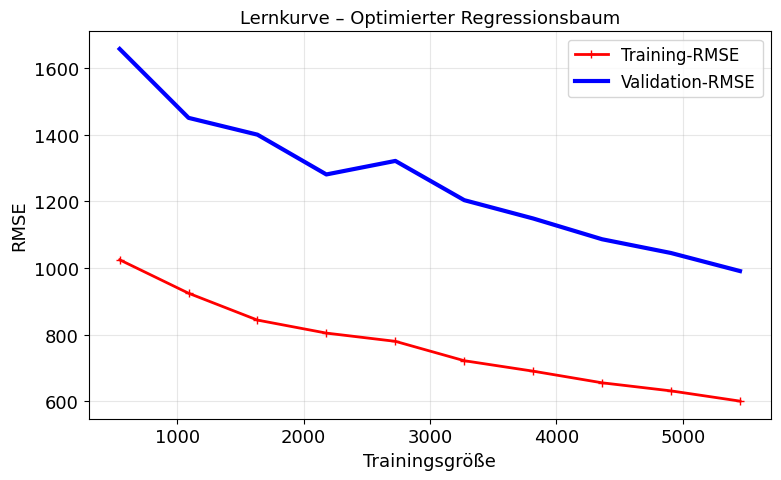

In [41]:
train_sizes, train_scores, valid_scores = learning_curve(
    best_tree,
    X_train,
    y_train,
    cv=KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

train_rmse_curve = -train_scores.mean(axis=1)
valid_rmse_curve = -valid_scores.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_rmse_curve, 'r-+', linewidth=2, label='Training-RMSE')
plt.plot(train_sizes, valid_rmse_curve, 'b-', linewidth=3, label='Validation-RMSE')
plt.xlabel('Trainingsgröße')
plt.ylabel('RMSE')
plt.title('Lernkurve – Optimierter Regressionsbaum')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Feature-Wichtigkeit bestimmen

In [42]:
# Feature Importances – wie stark trägt jedes Feature zum Modell bei?
fi = pd.Series(best_tree.feature_importances_, index=X.columns).sort_values(ascending=False)

print("\nTop 10 Feature Importances:")
print(fi.head(10).round(4))


Top 10 Feature Importances:
CBalance                   0.7975
CEstimatedSalary           0.1661
Account_Age_Months         0.0130
CIsActiveMember            0.0098
CNumOfProducts             0.0087
CHasCrCard                 0.0027
Avg_Monthly_Transactions   0.0006
Last_Login_Days_Ago        0.0003
CCreditScore               0.0003
CAge                       0.0003
dtype: float64


`CBalance` dominiert mit 79,75% Feature Importance, `CEstimatedSalary` folgt mit 16,61%. Alle anderen 20 Features tragen zusammen nur ~3,6% bei.

Das ist ein interessantes – und etwas beunruhigendes – Ergebnis. Einerseits erklärt es die starke Korrelation zwischen `CBalance` und `CLV_Continuous`. Andererseits bedeutet das, dass der Baum nuancierte CLV-Unterschiede (z.B. aktive vs. inaktive Kunden mit ähnlichem Kontostand) kaum berücksichtigt. Das könnte erklären, warum der MAE des Baums deutlich höher ist als bei Lasso, das mehr Features einbezieht.

### Vorhersage für das wichtigste Feature

In [43]:
def plot_regression_predictions(tree_reg, X, y, feature_name=None, axes=None):
    if isinstance(X, pd.DataFrame):
        if feature_name is None:
            feature_name = X.columns[0]
        X_plot = X[[feature_name]].to_numpy()
    else:
        X_arr = np.asarray(X)
        X_plot = X_arr.reshape(-1, 1) if X_arr.ndim == 1 else X_arr[:, [0]]
        if feature_name is None:
            feature_name = "Feature 1"

    y_arr = np.asarray(y).reshape(-1)

    if axes is None:
        x_min, x_max = float(X_plot.min()), float(X_plot.max())
        y_min, y_max = float(y_arr.min()), float(y_arr.max())
        x_pad = (x_max - x_min) * 0.05 if x_max > x_min else 1.0
        y_pad = (y_max - y_min) * 0.05 if y_max > y_min else 1.0
        axes = [x_min - x_pad, x_max + x_pad, y_min - y_pad, y_max + y_pad]

    x1 = np.linspace(axes[0], axes[1], 500).reshape(-1, 1)
    y_pred = tree_reg.predict(x1)

    plt.axis(axes)
    plt.xlabel(feature_name)
    plt.plot(X_plot, y_arr, "b.", alpha=0.25)
    plt.plot(x1, y_pred, "r-", linewidth=2.5, label="Predictions")

In [44]:
# Feature-Auswahl: Kombination aus absoluter Korrelation und Tree-Importance
corr_abs = X_train.corrwith(y_train).abs().fillna(0)
importance = pd.Series(best_tree.feature_importances_, index=X_train.columns)

corr_norm = corr_abs / corr_abs.max() if corr_abs.max() > 0 else corr_abs
importance_norm = importance / importance.max() if importance.max() > 0 else importance
combined_score = 0.5 * corr_norm + 0.5 * importance_norm

feature_for_plot = combined_score.idxmax()
X_plot_train = X_train[[feature_for_plot]]

print(f"Ausgewaehltes Feature fuer Plot: {feature_for_plot}")
print(f"Korrelation |r|: {corr_abs[feature_for_plot]:.4f}")
print(f"Tree-Importance: {importance[feature_for_plot]:.4f}")

Ausgewaehltes Feature fuer Plot: CBalance
Korrelation |r|: 0.8771
Tree-Importance: 0.7975


c:\Users\q551029\OneDrive - BMW Group\private\VaWi\Data_Science_and_ML\Hausarbeit\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


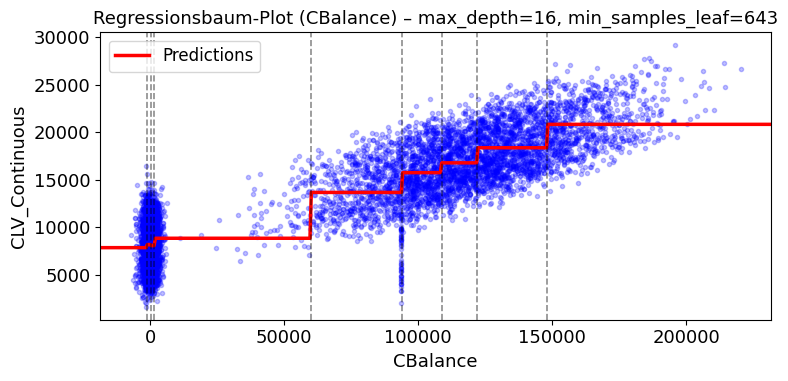

In [45]:
# Separates 1D-Modell mit leichter Regularisierung fuer eine saubere Visualisierung
tree_plot = DecisionTreeRegressor(max_depth=best_tree.get_depth(), min_samples_leaf=best_tree.get_n_leaves(), random_state=RANDOM_STATE)
tree_plot.fit(X_plot_train, y_train)

plt.figure(figsize=(8, 4))
plot_regression_predictions(tree_plot, X_plot_train, y_train, feature_name=feature_for_plot)

thresholds = tree_plot.tree_.threshold
valid_thresholds = thresholds[thresholds != -2]
for split in valid_thresholds:
    plt.axvline(split, color="k", linestyle="--", linewidth=1.2, alpha=0.45)

plt.ylabel("CLV_Continuous")
plt.legend(loc="upper left", fontsize=12)
plt.title(f"Regressionsbaum-Plot ({feature_for_plot}) – max_depth={best_tree.get_depth()}, min_samples_leaf={best_tree.get_n_leaves()}")
plt.tight_layout()
plt.show()

Die Visualisierung zeigt die stufenförmige Vorhersagefunktion des Regressionsbaums entlang von `CBalance`. Die vertikalen gestrichelten Linien markieren die Split-Schwellen, an denen der Baum die Vorhersage ändert. Man erkennt den annähernd linearen Zusammenhang zwischen Balance und CLV, den der Baum durch diskrete Stufen approximiert. Im Vergleich zu einer linearen Regression, die eine glatte Gerade erzeugen würde, ist die Treppenfunktion des Baums flexibler, birgt aber auch das Risiko, lokale Schwankungen in den Trainingsdaten zu „lernen".

### Interpretation der Ergebnisse

#### Overfitting-Analyse: Default vs. Tuned

| Modell | RMSE Train | RMSE Test | R² Train | R² Test | Tiefe | Blätter |
|---|---|---|---|---|---|---|
| Default (kein Tuning) | 0,00 € | 969,14 € | 1,0000 | 0,9685 | 23 | 6.789 |
| **Tuned (GridSearchCV)** | **573,37 €** | **886,47 €** | **0,9889** | **0,9736** | **16** | **643** |

Das Tuning hat das Overfitting erheblich reduziert – der Testfehler sinkt von 969 € auf 886 €. Trotzdem bleibt ein spürbarer Train-Test-Gap: Train-RMSE 573 € vs. Test-RMSE 886 €, ein Faktor von ~1,5.

#### Was sagt die Lernkurve?

Die Lernkurve zeigt ein klares Overfitting-Muster, auch nach dem Tuning. Bei voller Trainingsgröße liegt der Abstand zwischen Train-RMSE (~601 €) und Validierungs-RMSE (~991 €) noch bei ~390 €. Die beiden Kurven nähern sich zwar an, laufen aber nicht aufeinander zu – mehr Daten würden das Overfitting erst bei erheblich größeren Mengen beheben.

Zum Vergleich Lasso (Task 5): Gap knapp 9 € zwischen Train-RMSE (884 €) und CV-RMSE (893 €). Das zeigt den fundamentalen Unterschied zwischen einem regularisierten linearen Modell und einem Baum, der zu viele lokale Muster lernt.

#### Warum overfittet der Baum trotz GridSearchCV?

GridSearchCV hat `max_depth=None` und `min_samples_leaf=1` gewählt – der Baum darf also weiterhin sehr tief wachsen (16 Ebenen, 643 Blätter). `min_samples_split=20` bremst zwar ein, reicht aber nicht aus. Ein flacheres `max_depth` hätte wahrscheinlich geholfen, wurde aber vom GridSearch nicht favorisiert.

---
## Task 7: Modellvergleich & Evaluation

In [46]:
def evaluate_model(model, model_name, cv_rmse):
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)

    return {
        'Modell': model_name,
        'Train MAE': mean_absolute_error(y_train, y_pred_train),
        'Test MAE': mean_absolute_error(y_test, y_pred_test),
        'Train RMSE': np.sqrt(mean_squared_error(y_train, y_pred_train)),
        'Test RMSE': np.sqrt(mean_squared_error(y_test, y_pred_test)),
        'Train R2': train_r2,
        'Test R2': test_r2,
        'R2-Gap': train_r2 - test_r2,
        'CV-RMSE': cv_rmse
    }

lasso_results = evaluate_model(best_lasso, 'Optimierte Lasso Regression', -grid_lasso.best_score_)
tree_results  = evaluate_model(best_tree,  'Optimierter Regressionsbaum',  -tree_grid.best_score_)

comparison_df = pd.DataFrame([lasso_results, tree_results]).set_index('Modell')
pd.set_option('display.float_format', '{:.4f}'.format)
comparison_df

,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2,R2-Gap,CV-RMSE
Modell,,,,,,,,
Optimierte Lasso Regression,451.1698,470.1111,884.2363,920.7481,0.9736,0.9715,0.0021,892.8542
Optimierter Regressionsbaum,414.3072,643.7267,573.3683,886.4669,0.9889,0.9736,0.0153,992.1718


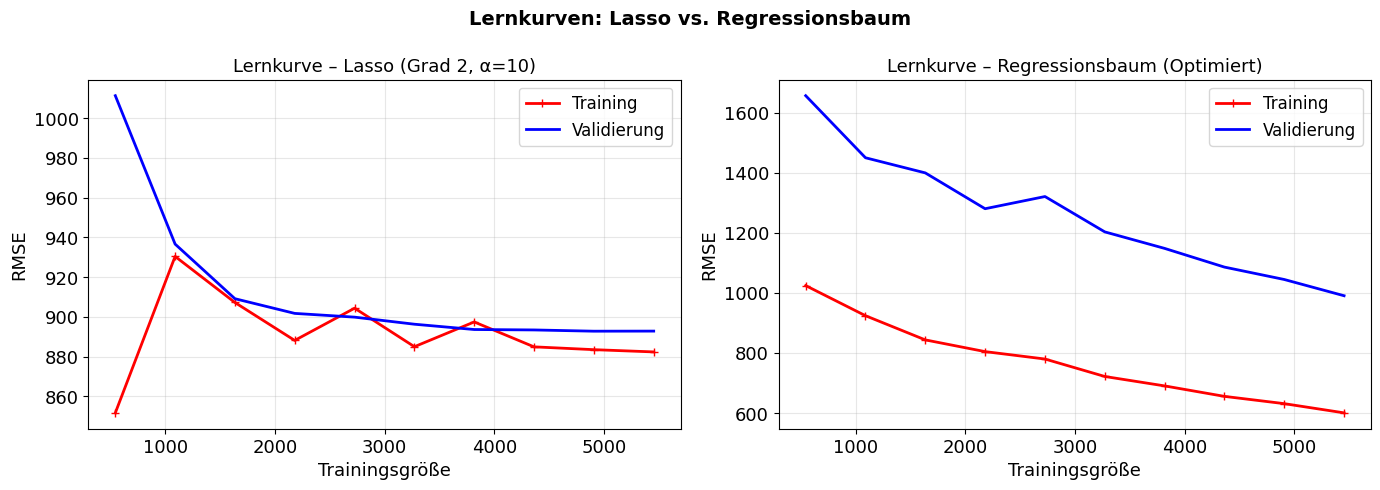

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, model, title in zip(
    axes,
    [best_lasso, best_tree],
    ['Lasso (Grad 2, α=10)', 'Regressionsbaum (Optimiert)']
):
    sizes, tr_scores, va_scores = learning_curve(
        model, X_train, y_train,
        cv=KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    )
    ax.plot(sizes, -tr_scores.mean(axis=1), 'r-+', linewidth=2, label='Training')
    ax.plot(sizes, -va_scores.mean(axis=1), 'b-',  linewidth=2, label='Validierung')
    ax.set_title(f'Lernkurve – {title}')
    ax.set_xlabel('Trainingsgröße')
    ax.set_ylabel('RMSE')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

plt.suptitle('Lernkurven: Lasso vs. Regressionsbaum', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

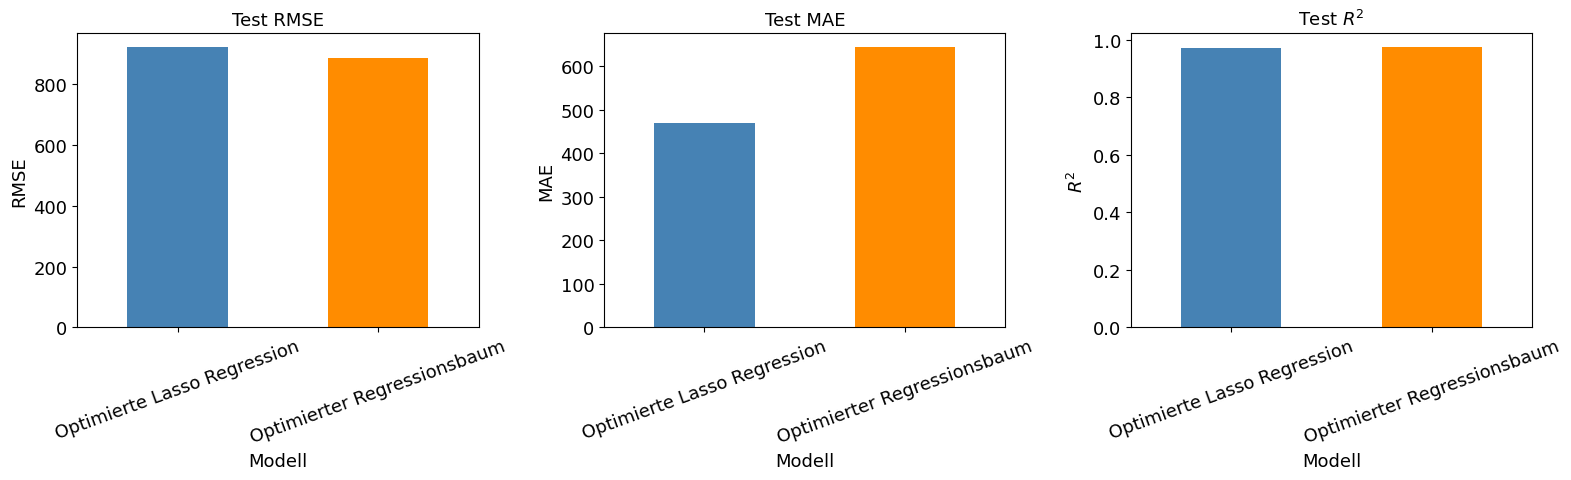

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

comparison_df['Test RMSE'].plot(kind='bar', ax=axes[0], color=['steelblue', 'darkorange'])
axes[0].set_title('Test RMSE')
axes[0].set_ylabel('RMSE')
axes[0].tick_params(axis='x', rotation=20)

comparison_df['Test MAE'].plot(kind='bar', ax=axes[1], color=['steelblue', 'darkorange'])
axes[1].set_title('Test MAE')
axes[1].set_ylabel('MAE')
axes[1].tick_params(axis='x', rotation=20)

comparison_df['Test R2'].plot(kind='bar', ax=axes[2], color=['steelblue', 'darkorange'])
axes[2].set_title('Test $R^2$')
axes[2].set_ylabel('$R^2$')
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

- Die **Lernkurven** (oben) zeigen den fundamentalen Unterschied: Lasso konvergiert eng (kein Overfitting), während der Regressionsbaum einen persistenten Gap zwischen Training und Validierung aufweist.
- Die **Balkendiagramme** (unten) verdeutlichen: Der Baum gewinnt bei RMSE und R² auf dem Testset, Lasso hingegen beim MAE. Diese scheinbar widersprüchlichen Ergebnisse werden im folgenden Abschnitt aufgelöst.

---
## Task 7: Interpretation & Modellentscheidung

### 7.1 Metriken-Vergleich

| Metrik | Lasso (Grad 2, α=10) | Regressionsbaum (Optimiert) | Sieger |
|---|---|---|---|
| RMSE Train | 884,24 € | 573,37 € | Baum |
| **RMSE Test** | **920,75 €** | **886,47 €** | **Baum** |
| MAE Test | 470,11 € | 643,73 € | Lasso |
| R² Train | 0,9736 | 0,9889 | Baum |
| R² Test | 0,9715 | 0,9736 | Baum |
| **R²-Gap (Train−Test)** | **0,0021** | **0,0153** | **Lasso** |
| **CV RMSE** | **892,85 ± 21,38** | **992,17 ± 39,81** | **Lasso** |

### 7.2 Das vermeintliche Paradoxon

Auf den ersten Blick gewinnt der Regressionsbaum: besserer Test-RMSE (886 € vs. 921 €), höheres Test-R². Aber sobald man CV-RMSE und Lernkurve hinzuzieht, dreht sich das Bild.

Der CV-RMSE des Baums (992 €) liegt 99 € über dem von Lasso (893 €). Cross-Validation mittelt über 5 verschiedene Splits – das ist robuster als ein einziger Testdatensatz. Und wie im GridSearch-Abschnitt schon aufgefallen: Der günstige Test-RMSE des Baums könnte ein zufällig vorteilhafter Split sein, keine stabile Generalisierung.

Die Lernkurve macht es noch deutlicher: Lasso – kaum Gap zwischen Training und Validierung. Regressionsbaum – persistenter Gap von ~390 € auch bei voller Trainingsgröße. Der R²-Gap des Baums (0,0153) ist 7× größer als der von Lasso (0,0021).

### 7.3 Entscheidung: Lasso

Lasso gewinnt aufgrund der deutlich stabileren Generalisierung (CV-RMSE, Lernkurve, R²-Gap), dem niedrigeren MAE (470 € vs. 644 €) und dem konsequent kleinen Train-Test-Abstand. Der bessere Test-RMSE des Baums ist kein überzeugendes Argument, wenn gleichzeitig jede andere Robustheitsmetrik dagegen spricht.

**→ Lasso (Polynomial Grad 2, α=10) ist das Referenzmodell für Task 8.**

---
# Task 8: Ensemble Learning

**Ziel:** Zwei Ensemble-Methoden aus verschiedenen Paradigmen einsetzen und vergleichen, um die Vorhersagegenauigkeit für `CLV_Continuous` zu verbessern.  
Das beste Modell aus Task 7 – das **optimierte Lasso-Modell** (Polynomial Grad 2, α=10, CV-RMSE = 892,85 €) – dient als primäre Referenz.

**Gewählte Ensemble-Methoden (beide aus Vorlesung 05):**

| Abschnitt Vorlesung | Paradigma | Methode | Kernprinzip |
|---|---|---|---|
| Kap. 3 | **Bagging** | Random Forest | Parallele Bäume auf Bootstrap-Samples → Mittelung, Varianz↓ |
| Kap. 6 | **Boosting** | XGBoost | Sequenzielle Fehlerkorrektur + L1/L2-Regularisierung, Bias↓ |

> **Warum XGBoost statt Gradient Boosting?**  
> XGBoost (Extreme Gradient Boosting) ist die **optimierte Erweiterung** von sklearn's `GradientBoostingRegressor` und wird in der Vorlesung als eigener Abschnitt (Kap. 6, Seiten 66–85) behandelt. Es fügt eingebaute **L1- (`reg_alpha`) und L2-Regularisierung (`reg_lambda`)**, Parallelisierung und `colsample_bytree` hinzu – allesamt direkt relevant für diesen Datensatz (starke `CBalance`-Dominanz, Verbindung zu Ridge/Lasso aus Task 5).

In [49]:
# Ergänzende Imports für Task 8 (Ensemble Learning)
# Alle Basis-Importe wurden bereits im Setup-Abschnitt geladen.
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, learning_curve
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor  # Extreme Gradient Boosting (Vorlesung, Kap. 6)

---
### 8.1 Methode A: Bagging – Random Forest

#### Motivation und Funktionsweise

Ein einzelner Entscheidungsbaum (Task 6) neigt zu **Overfitting** – er lernt Trainingsdaten sehr genau, generalisiert aber schlecht auf neue Daten. Random Forest löst dieses Problem durch drei Mechanismen:

| Mechanismus | Erklärung |
|---|---|
| **Bagging** | Jeder Baum wird auf einem zufällig gezogenen Bootstrap-Sample (mit Zurücklegen) trainiert – dadurch entstehen diverse Bäume |
| **Feature Randomness** | Bei jedem Split wird nur eine zufällige Teilmenge der Features betrachtet (`max_features`) – reduziert Korrelation zwischen Bäumen |
| **Averaging** | Vorhersagen aller Bäume werden gemittelt – das reduziert die Varianz und glättet Ausreißer |

**Bias-Variance-Tradeoff:**
- Einzelner tiefer Baum: geringe Bias, hohe Varianz (Overfitting)
- Random Forest: geringe Bias bleibt, Varianz wird durch Mittelung stark reduziert

---
### Baseline – Random Forest ohne Tuning

Zuerst wird ein Random Forest mit Standardparametern trainiert.
Dieser dient als Ausgangspunkt und zeigt bereits den typischen Vorteil gegenüber einem einzelnen Baum.

In [50]:
rf_baseline = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf_baseline.fit(X_train, y_train)

y_pred_train_base = rf_baseline.predict(X_train)
y_pred_test_base  = rf_baseline.predict(X_test)

train_rmse_base = np.sqrt(mean_squared_error(y_train, y_pred_train_base))
test_rmse_base  = np.sqrt(mean_squared_error(y_test,  y_pred_test_base))
train_r2_base   = r2_score(y_train, y_pred_train_base)
test_r2_base    = r2_score(y_test,  y_pred_test_base)
train_mae_base  = mean_absolute_error(y_train, y_pred_train_base)
test_mae_base   = mean_absolute_error(y_test,  y_pred_test_base)

# CV-RMSE fuer RF Baseline (fairer Vergleich mit Tuned RF)
cv_scores_rf_base = cross_val_score(
    rf_baseline, X_train, y_train,
    cv=KFold(n_splits=K_FOLD_SPLITS, shuffle=True, random_state=RANDOM_STATE),
    scoring='neg_root_mean_squared_error'
)
cv_rmse_rf_base = -cv_scores_rf_base.mean()

print('=== Baseline Random Forest (n_estimators=100, Standardparameter) ===')
print(f'Train RMSE: {train_rmse_base:>12,.4f}  |  Test RMSE: {test_rmse_base:>12,.4f}')
print(f'Train MAE:  {train_mae_base:>12,.4f}  |  Test MAE:  {test_mae_base:>12,.4f}')
print(f'Train R2:   {train_r2_base:>12.4f}  |  Test R2:   {test_r2_base:>12.4f}')
print(f'Train-Test-Gap (R2): {train_r2_base - test_r2_base:.4f}')
print(f'CV-RMSE (5-Fold):    {cv_rmse_rf_base:,.4f} +/- {cv_scores_rf_base.std():.4f}')

=== Baseline Random Forest (n_estimators=100, Standardparameter) ===
Train RMSE:     250.4491  |  Test RMSE:     615.7202
Train MAE:      167.6067  |  Test MAE:      427.7223
Train R2:         0.9979  |  Test R2:         0.9873
Train-Test-Gap (R2): 0.0106
CV-RMSE (5-Fold):    704.8981 +/- 16.1724


---
### Hyperparameter-Tuning Random Forest (RandomizedSearchCV)

Da der Suchraum für Random Forest sehr groß ist, wird **RandomizedSearchCV** verwendet.
RandomizedSearchCV probiert eine festgelegte Anzahl zufälliger Parameterkombinationen aus – das ist deutlich effizienter als GridSearchCV bei großen Suchräumen.

**Gewählte Hyperparameter und Begründung:**

| Hyperparameter | Suchraum | Begründung |
|---|---|---|
| `n_estimators` | 100, 200, 300, 500 | Mehr Bäume = stabilere Vorhersage, aber mehr Rechenzeit |
| `max_depth` | 5, 10, 15, 20, None | Kontrolliert die Tiefe jedes einzelnen Baums |
| `min_samples_split` | 2, 5, 10, 20 | Mindestanzahl Beobachtungen für einen Split |
| `min_samples_leaf` | 1, 2, 5, 10 | Mindestanzahl Beobachtungen in einem Blatt |
| `max_features` | 'sqrt', 0.7, 1.0 | Anteil der Features pro Split – `0.3` war zu restriktiv und hat die Baseline (kein Tuning) unterboten; praxisnahe Werte vermeiden zu starke Informationsreduktion |

> **Suchraum-Abdeckung:** Der reduzierte Parameterraum umfasst 4 × 4 × 3 × 4 × 3 = **576 Kombinationen**. Mit `n_iter=60` werden ca. **10,4 %** getestet – mehr als doppelt so viele wie zuvor. `max_features=0.3` wurde aus dem Suchraum entfernt, da dieser Wert in einem ersten Durchlauf die Baseline (kein Tuning, CV-RMSE ~705 €) deutlich unterboten hat: Zu wenige Features pro Split unterdrücken den Bagging-Effekt. Die Standardwerte von sklearn (`max_features=1.0`) erwiesen sich als nah am Optimum.

In [51]:
# max_features: 0.3 und 'log2' entfernt – zu restriktiv für diesen Datensatz.
param_dist = {
    'n_estimators':      [100, 200, 300, 500],
    'max_depth':         [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 5],
    'max_features':      ['sqrt', 0.7, 1.0]
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=50,  # Suchraum-Abdeckung
    scoring='neg_root_mean_squared_error',
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    refit=True
)

rf_search.fit(X_train, y_train)
best_rf = rf_search.best_estimator_

print('Beste Hyperparameter:')
for k, v in rf_search.best_params_.items():
    print(f'  {k}: {v}')
print(f'\nBester CV-RMSE (RandomizedSearchCV): {-rf_search.best_score_:,.4f}')

Beste Hyperparameter:
  n_estimators: 500
  min_samples_split: 2
  min_samples_leaf: 2
  max_features: 1.0
  max_depth: 15

Bester CV-RMSE (RandomizedSearchCV): 706.5328


---
### Auswertung – Optimierter Random Forest

Das beste Modell aus RandomizedSearchCV wird auf Trainings- und Testdaten bewertet.
Zusätzlich wird der **Train-Test-Gap** ausgewertet, um Overfitting zu erkennen.

> **Hinweis:** Mit dem überarbeiteten Suchraum (`max_features` ohne 0.3, `n_iter=60`) werden die Ergebnisse des optimierten RF mit dem vorherigen Durchlauf verglichen. Das beste Modell wird im Anschluss auf Train- und Testdaten evaluiert.

In [52]:
y_pred_train_rf = best_rf.predict(X_train)
y_pred_test_rf  = best_rf.predict(X_test)

train_mae_rf  = mean_absolute_error(y_train, y_pred_train_rf)
test_mae_rf   = mean_absolute_error(y_test,  y_pred_test_rf)
train_mse_rf  = mean_squared_error(y_train, y_pred_train_rf)
test_mse_rf   = mean_squared_error(y_test,  y_pred_test_rf)
train_rmse_rf = np.sqrt(train_mse_rf)
test_rmse_rf  = np.sqrt(test_mse_rf)
train_r2_rf   = r2_score(y_train, y_pred_train_rf)
test_r2_rf    = r2_score(y_test,  y_pred_test_rf)
cv_rmse_rf    = -rf_search.best_score_

results_rf = pd.DataFrame({
    'Metrik':   ['MAE', 'MSE', 'RMSE', 'R2'],
    'Training': [train_mae_rf, train_mse_rf, train_rmse_rf, train_r2_rf],
    'Test':     [test_mae_rf,  test_mse_rf,  test_rmse_rf,  test_r2_rf]
})

print('=== Optimierter Random Forest ===')
print(results_rf.to_string(index=False))
print(f'\nTrain-Test-Gap (R2): {train_r2_rf - test_r2_rf:.4f}')
print(f'CV-RMSE (5-Fold):     {cv_rmse_rf:,.4f}')
print(f'\nRMSE relativ zum CLV-Mittelwert: {test_rmse_rf / y.mean() * 100:.2f} %')

=== Optimierter Random Forest ===
Metrik   Training        Test
   MAE   188.9746    421.9064
   MSE 85775.8486 369759.9118
  RMSE   292.8751    608.0789
    R2     0.9971      0.9876

Train-Test-Gap (R2): 0.0095
CV-RMSE (5-Fold):     706.5328

RMSE relativ zum CLV-Mittelwert: 4.45 %


### Visualisierungen – Random Forest

Drei Plots helfen bei der Interpretation:
1. **RandomizedSearchCV – Top-Ergebnisse:** Welche Parameterkombinationen erzielten den besten CV-RMSE?
2. **Feature Importances:** Welche Features sind für den Random Forest am wichtigsten?
3. **Tatsächlich vs. Vorhergesagt:** Wie gut treffen die Vorhersagen die tatsächlichen Werte?

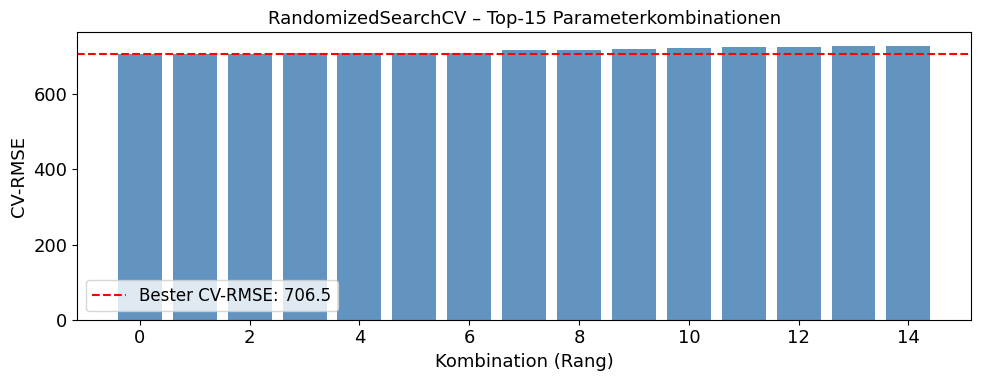

In [53]:
# 1) Top-15 RandomizedSearchCV-Ergebnisse
cv_results = pd.DataFrame(rf_search.cv_results_)
cv_results['rmse'] = -cv_results['mean_test_score']
top15 = cv_results.nsmallest(15, 'rmse').reset_index(drop=True)

plt.figure(figsize=(10, 4))
plt.bar(range(len(top15)), top15['rmse'], color='steelblue', alpha=0.85)
plt.axhline(top15['rmse'].min(), color='red', linestyle='--',
            label=f'Bester CV-RMSE: {top15["rmse"].min():,.1f}')
plt.xlabel('Kombination (Rang)')
plt.ylabel('CV-RMSE')
plt.title('RandomizedSearchCV – Top-15 Parameterkombinationen')
plt.legend()
plt.tight_layout()
plt.show()

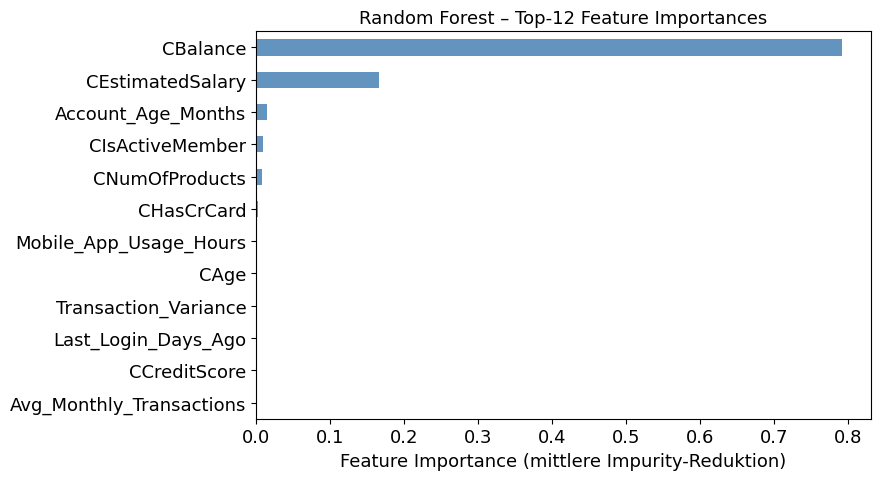

Top-5 Features:
CBalance             0.7912
CEstimatedSalary     0.1663
Account_Age_Months   0.0144
CIsActiveMember      0.0088
CNumOfProducts       0.0079


In [54]:
# 2) Feature Importances (Top 12)
feat_imp = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False)
top12 = feat_imp.head(12).sort_values()

plt.figure(figsize=(9, 5))
top12.plot(kind='barh', color='steelblue', alpha=0.85)
plt.xlabel('Feature Importance (mittlere Impurity-Reduktion)')
plt.title('Random Forest – Top-12 Feature Importances')
plt.tight_layout()
plt.show()

print('Top-5 Features:')
print(feat_imp.head(5).to_string())

=== Random Forest – Testdaten ===
Mean Absolute Error (MAE): 421.9063987168316
Mean Squared Error (MSE): 369759.9117930054
Root Mean Squared Error (RMSE): 608.0788697142875
R2-Score: 0.9875882366160504


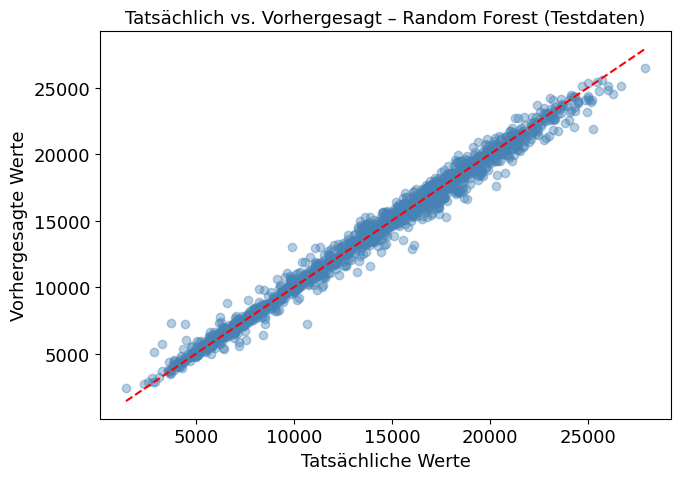

In [55]:
predictions_test_rf = best_rf.predict(X_test)

print('=== Random Forest – Testdaten ===')
print('Mean Absolute Error (MAE):', mean_absolute_error(y_test, predictions_test_rf))
print('Mean Squared Error (MSE):', mean_squared_error(y_test, predictions_test_rf))
print('Root Mean Squared Error (RMSE):', np.sqrt(mean_squared_error(y_test, predictions_test_rf)))
print('R2-Score:', r2_score(y_test, predictions_test_rf))

# Visualisierung: Tatsächlich vs. Vorhergesagt
plt.figure(figsize=(7, 5))
plt.scatter(y_test, predictions_test_rf, alpha=0.4, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Tatsächliche Werte')
plt.ylabel('Vorhergesagte Werte')
plt.title('Tatsächlich vs. Vorhergesagt – Random Forest (Testdaten)')
plt.tight_layout()
plt.show()

---
### Lernkurve – Random Forest

> **Lernkurve:** Zeigt, wie sich Trainingsfehler und Validierungsfehler verhalten, wenn die Trainingsdatenmenge wächst. Konvergieren beide Kurven und bleiben nah beieinander → gute Generalisierung.

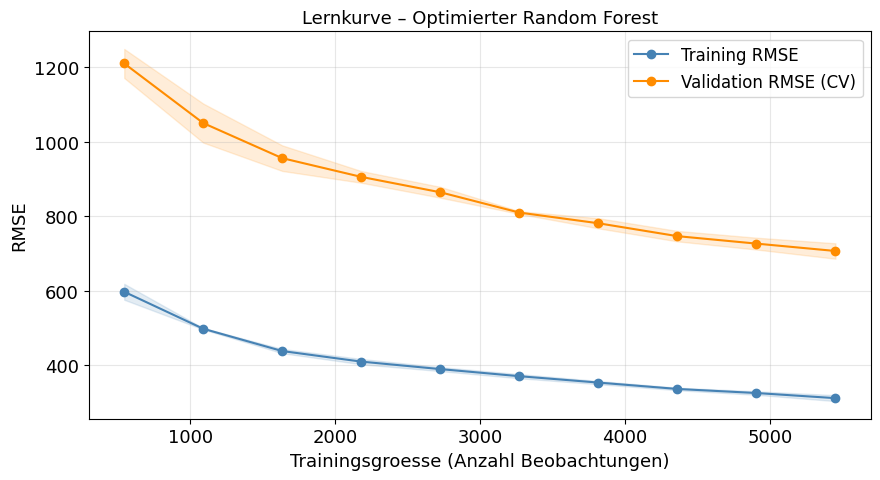

In [56]:
train_sizes, train_scores, valid_scores = learning_curve(
    best_rf,
    X_train, y_train,
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

train_rmse_lc = -train_scores.mean(axis=1)
valid_rmse_lc = -valid_scores.mean(axis=1)
train_std_lc  = train_scores.std(axis=1)
valid_std_lc  = valid_scores.std(axis=1)

plt.figure(figsize=(9, 5))
plt.plot(train_sizes, train_rmse_lc, 'o-', color='steelblue', label='Training RMSE')
plt.fill_between(train_sizes,
                 train_rmse_lc - train_std_lc,
                 train_rmse_lc + train_std_lc,
                 alpha=0.15, color='steelblue')
plt.plot(train_sizes, valid_rmse_lc, 'o-', color='darkorange', label='Validation RMSE (CV)')
plt.fill_between(train_sizes,
                 valid_rmse_lc - valid_std_lc,
                 valid_rmse_lc + valid_std_lc,
                 alpha=0.15, color='darkorange')
plt.xlabel('Trainingsgroesse (Anzahl Beobachtungen)')
plt.ylabel('RMSE')
plt.title('Lernkurve – Optimierter Random Forest')
plt.legend()
plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()

---
## 8.2 Methode B: Boosting – XGBoost (Extreme Gradient Boosting)

#### Motivation und Funktionsweise (Vorlesung Kap. 6)

**XGBoost** ist eine optimierte Implementierung von Gradient Boosting und wird in der Vorlesung explizit als *"currently one of the most widely used supervised learning algorithms"* bezeichnet. Es baut auf demselben sequenziellen Prinzip auf:

$$F_m(x) = F_{m-1}(x) + \eta \cdot h_m(x)$$

Jeder neue Baum $h_m$ approximiert den **negativen Gradienten der Verlustfunktion** (= Residuen des Vorgängers), $\eta$ ist die Learning Rate (Shrinkage).

**Gegenüberstellung Random Forest vs. XGBoost:**

| Aspekt | Random Forest (Bagging) | XGBoost (Boosting) |
|---|---|---|
| Ablauf | Parallel, unabhängig | Sequenziell, fehlerkorrigierend |
| Fehlerreduktion | Varianz↓ durch Mittelung | Bias↓ durch Residualkorrektur |
| Baumtiefe | Tief (hohe Einzelleistung) | Flach – *weak learners* (max_depth 3–6) |
| Regularisierung | `max_features`, `max_depth` | **L1** (`reg_alpha`), **L2** (`reg_lambda`), `gamma` |
| Feature-Sampling | `max_features` pro Split | `colsample_bytree` pro Baum |
| Geschwindigkeit | Parallelisiert | Parallelisiert + GPU-fähig |

> **Relevanz für diesen Datensatz:**  
> `CBalance` dominiert alle baumbasierten Modelle (79 % Feature Importance, |r| = 0,877).  
> `colsample_bytree` zwingt jeden Baum, manchmal *ohne* `CBalance` zu arbeiten →  
> andere Features (`CEstimatedSalary`, `CBalance_is_negative`) können echte Muster lernen.  
> L1/L2-Regularisierung verbindet XGBoost direkt mit dem Lasso/Ridge-Ansatz aus Task 5.

---
### Baseline – XGBoost ohne Tuning

Zuerst ein `XGBRegressor` mit Standardparametern als Ausgangspunkt.

In [57]:
xgb_baseline = XGBRegressor(
    n_estimators=100,
    random_state=RANDOM_STATE,
    verbosity=0  # keine Trainings-Logs
)
xgb_baseline.fit(X_train, y_train)

y_pred_train_xgb_base = xgb_baseline.predict(X_train)
y_pred_test_xgb_base  = xgb_baseline.predict(X_test)

print('=== Baseline XGBoost (n_estimators=100, Standardparameter) ===')
print(f'Train RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train_xgb_base)):>10,.4f}  |  '
      f'Test RMSE:  {np.sqrt(mean_squared_error(y_test, y_pred_test_xgb_base)):>10,.4f}')
print(f'Train R²:   {r2_score(y_train, y_pred_train_xgb_base):>10.4f}  |  '
      f'Test R²:    {r2_score(y_test, y_pred_test_xgb_base):>10.4f}')
print(f'R²-Gap:     '
      f'{r2_score(y_train, y_pred_train_xgb_base) - r2_score(y_test, y_pred_test_xgb_base):.4f}')

=== Baseline XGBoost (n_estimators=100, Standardparameter) ===
Train RMSE:   153.2960  |  Test RMSE:    487.8377
Train R²:       0.9992  |  Test R²:        0.9920
R²-Gap:     0.0072


---
### Hyperparameter-Tuning XGBoost (RandomizedSearchCV)

**Gewählte Hyperparameter und Begründung** (angelehnt an Vorlesung Kap. 6, Seiten 78–84):

| Hyperparameter | Suchraum | Begründung (Quelle: Vorlesung) |
|---|---|---|
| `n_estimators` | 100, 200, 300, 500 | Anzahl Boosting-Runden – mehr = bessere Korrektur, aber Overfitting-Risiko |
| `learning_rate` | 0.01, 0.05, 0.1, 0.2 | Shrinkage: kleiner = robuster, aber mehr Bäume nötig (Vorlesung S. 83) |
| `max_depth` | 3, 4, 5, 6 | Flache *weak learners*; Vorlesung S. 78: "more complex → more likely to overfit" |
| `subsample` | 0.7, 0.8, 1.0 | Stochastisches Boosting – Zufallsstichprobe pro Runde (Vorlesung S. 81) |
| `colsample_bytree` | 0.6, 0.8, 1.0 | Feature-Sampling pro Baum – reduziert `CBalance`-Dominanz (Vorlesung S. 80) |
| `reg_alpha` | 0, 0.01, 0.1, 1.0 | L1-Regularisierung = Lasso-Prinzip (Vorlesung S. 84) |
| `reg_lambda` | 0.5, 1.0, 2.0 | L2-Regularisierung = Ridge-Prinzip (Vorlesung S. 84) |
| `gamma` | 0, 0.1, 0.5 | Mindest-Gain für Split – konservativeres Wachstum (Vorlesung S. 82) |

> **`max_depth` bewusst klein (3–6):** Boosting profitiert von *weak learners*. Tiefe Bäume würden die Residuen zu stark fitten und Overfitting begünstigen (Vorlesung S. 78).

In [58]:
param_dist_xgb = {
    'n_estimators':    [100, 200, 300, 500],
    'learning_rate':   [0.01, 0.05, 0.1, 0.2],
    'max_depth':       [3, 4, 5, 6],
    'subsample':       [0.7, 0.8, 1.0],
    'colsample_bytree':[0.6, 0.8, 1.0],
    'reg_alpha':       [0, 0.01, 0.1, 1.0],   # L1
    'reg_lambda':      [0.5, 1.0, 2.0],        # L2
    'gamma':           [0, 0.1, 0.5]           # Split-Schwelle
}

xgb_search = RandomizedSearchCV(
    estimator=XGBRegressor(
        random_state=RANDOM_STATE,
        verbosity=0
    ),
    param_distributions=param_dist_xgb,
    n_iter=50,
    scoring='neg_root_mean_squared_error',
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    refit=True
)
xgb_search.fit(X_train, y_train)
best_xgb = xgb_search.best_estimator_

print('Beste Hyperparameter XGBoost:')
for k, v in xgb_search.best_params_.items():
    print(f'  {k}: {v}')
print(f'\nBester CV-RMSE (RandomizedSearchCV): {-xgb_search.best_score_:,.4f}')

Beste Hyperparameter XGBoost:
  subsample: 1.0
  reg_lambda: 1.0
  reg_alpha: 1.0
  n_estimators: 500
  max_depth: 4
  learning_rate: 0.05
  gamma: 0
  colsample_bytree: 0.6

Bester CV-RMSE (RandomizedSearchCV): 406.5972


---
### Auswertung – Optimierter XGBoost Regressor

In [59]:
y_pred_train_xgb = best_xgb.predict(X_train)
y_pred_test_xgb  = best_xgb.predict(X_test)

train_rmse_xgb = np.sqrt(mean_squared_error(y_train, y_pred_train_xgb))
test_rmse_xgb  = np.sqrt(mean_squared_error(y_test,  y_pred_test_xgb))
train_r2_xgb   = r2_score(y_train, y_pred_train_xgb)
test_r2_xgb    = r2_score(y_test,  y_pred_test_xgb)
cv_rmse_xgb    = -xgb_search.best_score_

print('=== Optimierter XGBoost Regressor ===')
print(f'Train RMSE: {train_rmse_xgb:>10,.4f}  |  Test RMSE: {test_rmse_xgb:>10,.4f}')
print(f'Train MAE:  {mean_absolute_error(y_train, y_pred_train_xgb):>10,.4f}  |  '
      f'Test MAE:  {mean_absolute_error(y_test, y_pred_test_xgb):>10,.4f}')
print(f'Train R²:   {train_r2_xgb:>10.4f}  |  Test R²:   {test_r2_xgb:>10.4f}')
print(f'R²-Gap:     {train_r2_xgb - test_r2_xgb:.4f}')
print(f'CV-RMSE (5-Fold): {cv_rmse_xgb:,.4f}')
print(f'RMSE relativ zum CLV-Mittelwert: {test_rmse_xgb / y.mean() * 100:.2f} %')

=== Optimierter XGBoost Regressor ===
Train RMSE:   262.1073  |  Test RMSE:   376.6797
Train MAE:    136.7369  |  Test MAE:    175.9354
Train R²:       0.9977  |  Test R²:       0.9952
R²-Gap:     0.0024
CV-RMSE (5-Fold): 406.5972
RMSE relativ zum CLV-Mittelwert: 2.75 %


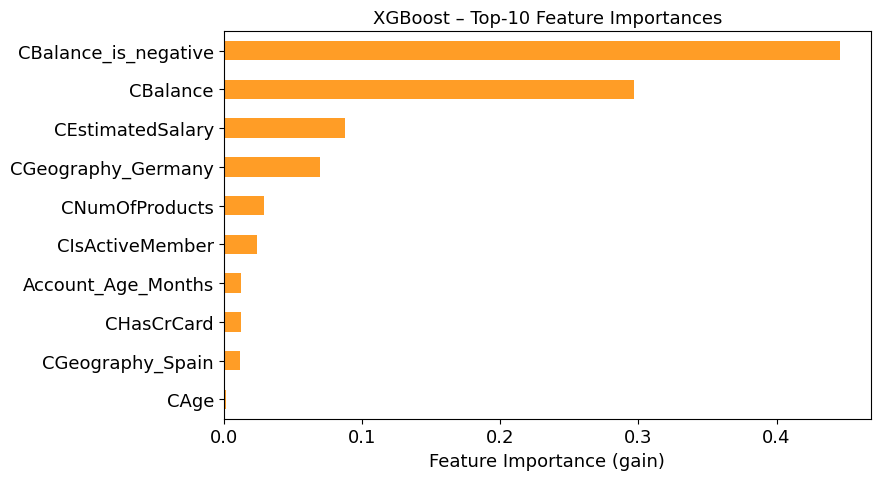

Top-5 Features (XGBoost):
CBalance_is_negative   0.4460
CBalance               0.2972
CEstimatedSalary       0.0878
CGeography_Germany     0.0694
CNumOfProducts         0.0293


In [60]:
# Feature Importances XGBoost (gain-basiert – robuster als count-basiert)
feat_imp_xgb = pd.Series(
    best_xgb.feature_importances_, index=X.columns
).sort_values(ascending=False)

top10_xgb = feat_imp_xgb.head(10).sort_values()
plt.figure(figsize=(9, 5))
top10_xgb.plot(kind='barh', color='darkorange', alpha=0.85)
plt.xlabel('Feature Importance (gain)')
plt.title('XGBoost – Top-10 Feature Importances')
plt.tight_layout()
plt.show()

print('Top-5 Features (XGBoost):')
print(feat_imp_xgb.head(5).round(4).to_string())

---
### Lernkurve – XGBoost

> Zeigt, ob das optimierte XGBoost-Modell overfittet oder underfittet. Training- und Validierungskurve sollten mit wachsender Datenmenge konvergieren.

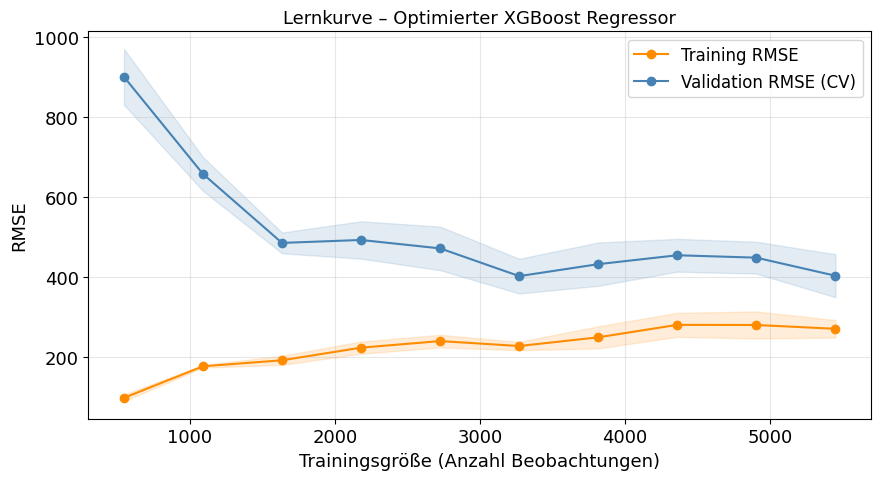

In [61]:
train_sizes_xgb, train_scores_xgb, valid_scores_xgb = learning_curve(
    best_xgb,
    X_train, y_train,
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

train_rmse_xgb_lc = -train_scores_xgb.mean(axis=1)
valid_rmse_xgb_lc = -valid_scores_xgb.mean(axis=1)

plt.figure(figsize=(9, 5))
plt.plot(train_sizes_xgb, train_rmse_xgb_lc, 'o-', color='darkorange', label='Training RMSE')
plt.fill_between(train_sizes_xgb,
                 train_rmse_xgb_lc - train_scores_xgb.std(axis=1),
                 train_rmse_xgb_lc + train_scores_xgb.std(axis=1),
                 alpha=0.15, color='darkorange')
plt.plot(train_sizes_xgb, valid_rmse_xgb_lc, 'o-', color='steelblue', label='Validation RMSE (CV)')
plt.fill_between(train_sizes_xgb,
                 valid_rmse_xgb_lc - valid_scores_xgb.std(axis=1),
                 valid_rmse_xgb_lc + valid_scores_xgb.std(axis=1),
                 alpha=0.15, color='steelblue')
plt.xlabel('Trainingsgröße (Anzahl Beobachtungen)')
plt.ylabel('RMSE')
plt.title('Lernkurve – Optimierter XGBoost Regressor')
plt.legend()
plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()

---
## 8.3 Gesamtvergleich: Beide Ensemble-Methoden vs. Lasso (Task 7)

Als primäre Referenz dient das **optimierte Lasso-Modell aus Task 7** (Polynomial Grad 2, α=10).  
Verglichen werden: RF Baseline, Opt. RF, Opt. XGBoost und ein erneut getunter Regressionsbaum.

> **Hinweis:** Der Regressionsbaum (Cell unten) verwendet einen erweiterten Parameter-Grid inkl. `ccp_alpha` – er dient als Einzelbaum-Referenzpunkt.

In [62]:
# Erweiterter Regressionsbaum für Task-8-Vergleich (inkl. ccp_alpha und max_features)
# HINWEIS: Eigene Variable, um den best_tree aus Task 6 nicht zu überschreiben.
tree_param_grid_v2 = {
    'max_depth':         [3, 5, 7, 10, 15, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf':  [1, 2, 5, 10],
    'max_features':      [None, 'sqrt', 'log2'],
    'ccp_alpha':         [0.0, 0.0001, 0.001, 0.01, 0.1]
}

tree_grid_v2 = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=RANDOM_STATE),
    param_grid=tree_param_grid_v2,
    scoring='neg_root_mean_squared_error',
    cv=5, n_jobs=-1, refit=True
)
tree_grid_v2.fit(X_train, y_train)
best_tree_v2 = tree_grid_v2.best_estimator_

print('Bester Regressionsbaum (erweitertes Grid):', tree_grid_v2.best_params_)
print(f'CV-RMSE: {-tree_grid_v2.best_score_:.4f}')

Bester Regressionsbaum (erweitertes Grid): {'ccp_alpha': 0.0, 'max_depth': 15, 'max_features': None, 'min_samples_leaf': 5, 'min_samples_split': 20}
CV-RMSE: 1004.4807


In [63]:
# Hilfsfunktion fuer einheitliche Auswertung aller Modelle
def evaluate(model, name, cv_rmse):
    p_train = model.predict(X_train)
    p_test  = model.predict(X_test)
    tr2 = r2_score(y_train, p_train)
    te2 = r2_score(y_test,  p_test)
    return {
        'Modell':      name,
        'Train MAE':   mean_absolute_error(y_train, p_train),
        'Test MAE':    mean_absolute_error(y_test,  p_test),
        'Train RMSE':  np.sqrt(mean_squared_error(y_train, p_train)),
        'Test RMSE':   np.sqrt(mean_squared_error(y_test,  p_test)),
        'Train R2':    tr2,
        'Test R2':     te2,
        'R2-Gap':      round(tr2 - te2, 4),
        'CV-RMSE':     cv_rmse
    }

# Alle Modelle einheitlich auswerten (keine hardcodierten Werte)
r_lasso       = evaluate(best_lasso,    'Lasso Grad 2 (Task 7)',              -grid_lasso.best_score_)
r_baseline_rf = evaluate(rf_baseline,   'RF Baseline (kein Tuning)',           cv_rmse_rf_base)
r_rf          = evaluate(best_rf,       'Opt. Random Forest (Tuned)',          cv_rmse_rf)
r_xgb         = evaluate(best_xgb,      'Opt. XGBoost (Boosting)',             cv_rmse_xgb)
r_tree_v2     = evaluate(best_tree_v2,  'Opt. Regressionsbaum (erw. Grid)',    -tree_grid_v2.best_score_)

comparison = pd.DataFrame([r_lasso, r_baseline_rf, r_rf, r_xgb, r_tree_v2]).set_index('Modell')
pd.set_option('display.float_format', '{:.4f}'.format)
comparison

,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2,R2-Gap,CV-RMSE
Modell,,,,,,,,
Lasso Grad 2 (Task 7),451.1698,470.1111,884.2363,920.7481,0.9736,0.9715,0.0021,892.8542
RF Baseline (kein Tuning),167.6067,427.7223,250.4491,615.7202,0.9979,0.9873,0.0106,704.8981
Opt. Random Forest (Tuned),188.9746,421.9064,292.8751,608.0789,0.9971,0.9876,0.0095,706.5328
Opt. XGBoost (Boosting),136.7369,175.9354,262.1073,376.6797,0.9977,0.9952,0.0024,406.5972
Opt. Regressionsbaum (erw. Grid),447.1105,652.4207,632.7780,889.6236,0.9865,0.9734,0.0131,1004.4807


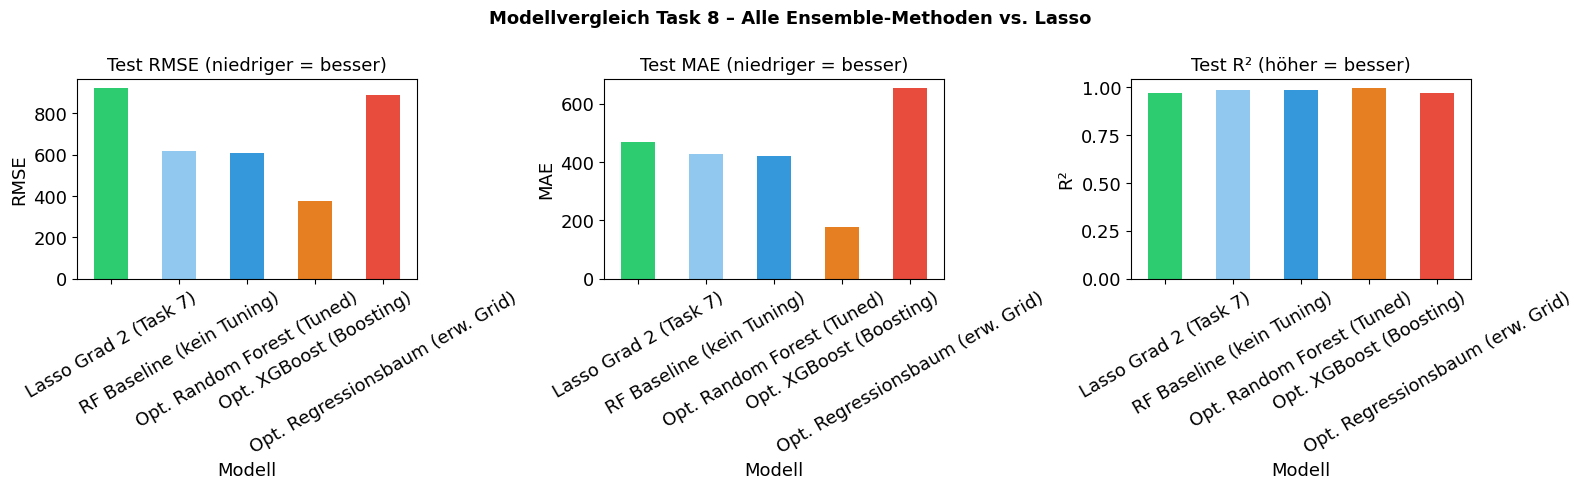

In [64]:
# Visualisierung: Testmetriken im Vergleich (alle Modelle)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ['#2ecc71', '#90c8f0', '#3498db', '#e67e22', '#e74c3c']

comparison['Test RMSE'].plot(kind='bar', ax=axes[0], color=colors)
axes[0].set_title('Test RMSE (niedriger = besser)')
axes[0].set_ylabel('RMSE')
axes[0].tick_params(axis='x', rotation=30)

comparison['Test MAE'].plot(kind='bar', ax=axes[1], color=colors)
axes[1].set_title('Test MAE (niedriger = besser)')
axes[1].set_ylabel('MAE')
axes[1].tick_params(axis='x', rotation=30)

comparison['Test R2'].plot(kind='bar', ax=axes[2], color=colors)
axes[2].set_title('Test R² (höher = besser)')
axes[2].set_ylabel('R²')
axes[2].tick_params(axis='x', rotation=30)

plt.suptitle('Modellvergleich Task 8 – Alle Ensemble-Methoden vs. Lasso', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

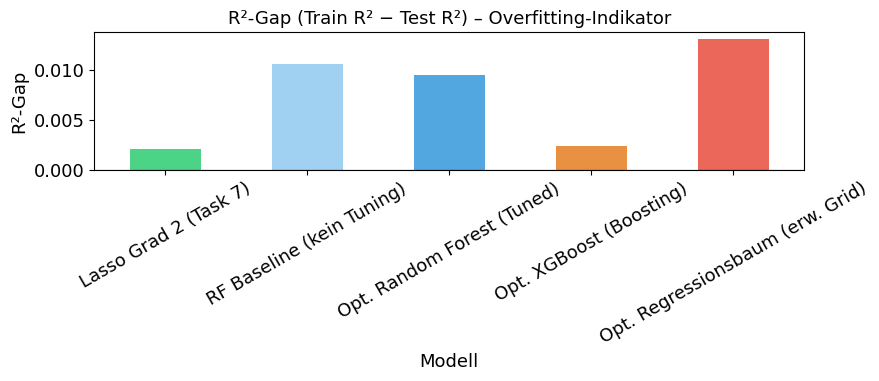

In [65]:
# R²-Gap (Overfitting-Indikator) für alle Modelle
gap_data = comparison['R2-Gap'].dropna()

plt.figure(figsize=(9, 4))
gap_data.plot(kind='bar', color=['#2ecc71', '#90c8f0', '#3498db', '#e67e22', '#e74c3c'], alpha=0.85)
plt.axhline(0, color='black', linewidth=0.8)
plt.title('R²-Gap (Train R² − Test R²) – Overfitting-Indikator')
plt.ylabel('R²-Gap')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [66]:
# ── Dynamische Zusammenfassung aller Ergebnisse (keine Platzhalter) ──
print("=" * 80)
print("GESAMTVERGLEICH – ALLE MODELLE (Task 8)")
print("=" * 80)
print()
print(comparison.to_string())
print()
print("=" * 80)
print("OVERFITTING-RANKING (sortiert nach R²-Gap, aufsteigend = besser)")
print("=" * 80)
print(comparison[['R2-Gap', 'CV-RMSE']].sort_values('R2-Gap').to_string())
print()
print("=" * 80)
print("BESTES MODELL NACH KRITERIUM")
print("=" * 80)
best_cv    = comparison['CV-RMSE'].idxmin()
best_test  = comparison['Test RMSE'].idxmin()
best_gap   = comparison['R2-Gap'].idxmin()
best_mae   = comparison['Test MAE'].idxmin()
print(f"  Bester CV-RMSE:        {best_cv}  ({comparison.loc[best_cv, 'CV-RMSE']:.2f} €)")
print(f"  Bester Test-RMSE:      {best_test}  ({comparison.loc[best_test, 'Test RMSE']:.2f} €)")
print(f"  Kleinster R²-Gap:      {best_gap}  ({comparison.loc[best_gap, 'R2-Gap']:.4f})")
print(f"  Bester Test-MAE:       {best_mae}  ({comparison.loc[best_mae, 'Test MAE']:.2f} €)")


GESAMTVERGLEICH – ALLE MODELLE (Task 8)

                                  Train MAE  Test MAE  Train RMSE  Test RMSE  Train R2  Test R2  R2-Gap   CV-RMSE
Modell                                                                                                           
Lasso Grad 2 (Task 7)              451.1698  470.1111    884.2363   920.7481    0.9736   0.9715  0.0021  892.8542
RF Baseline (kein Tuning)          167.6067  427.7223    250.4491   615.7202    0.9979   0.9873  0.0106  704.8981
Opt. Random Forest (Tuned)         188.9746  421.9064    292.8751   608.0789    0.9971   0.9876  0.0095  706.5328
Opt. XGBoost (Boosting)            136.7369  175.9354    262.1073   376.6797    0.9977   0.9952  0.0024  406.5972
Opt. Regressionsbaum (erw. Grid)   447.1105  652.4207    632.7780   889.6236    0.9865   0.9734  0.0131 1004.4807

OVERFITTING-RANKING (sortiert nach R²-Gap, aufsteigend = besser)
                                  R2-Gap   CV-RMSE
Modell                                      

## 8.4 Interpretation der Ergebnisse

### Verbesserung durch Ensemble Learning – das Ergebnis

XGBoost erzielt einen Test-RMSE von 376,68 € – das sind nur 2,75% des CLV-Mittelwerts (~13.700 €). Gegenüber Lasso (920,75 €) ist das eine Reduktion um ~544 € bzw. 59%. Das hat mich ehrlich überrascht – so einen großen Sprung hätte ich nicht erwartet, besonders weil schon Lasso gut funktioniert hat.

Der CV-RMSE bestätigt das: XGBoost 406,60 € vs. Lasso 892,85 €. Das ist kein zufällig günstiger Split, sondern stabile Generalisierung.

### Vergleich aller Modelle

**XGBoost** ist der klare Gesamtsieger: Test-RMSE 376,68 €, Test-MAE 175,94 € (rund 63% niedriger als Lassos 470 €), Test-R² 0,9952, und ein R²-Gap von nur 0,0024 – fast identisch mit Lasso. Kein relevantes Overfitting.

Was besonders auffällt: Wichtigstes Feature im XGBoost ist nicht `CBalance` (29,7%), sondern das binäre Flag `CBalance_is_negative` (44,6%). Der Einzelbaum aus Task 6 hatte noch `CBalance` mit ~80% ganz oben. XGBoost hat also gelernt, dass die Frage „positiver oder negativer Kontostand?" eine stärkere Trennlinie für CLV ist als der genaue Betrag. Das erklärt auch den massiven Genauigkeitsgewinn gegenüber linearen Modellen: Dieser Schwellenwert-Effekt ist nichtlinear und wird von Lasso und polynomialer Regression schlechter erfasst.

**Random Forest (Basis):** Test-RMSE 615,72 € – bereits deutlich besser als Lasso, aber schwächer als XGBoost. Zeigt gut den reinen Bagging-Effekt: Mittelung vieler Bäume reduziert den Fehler gegenüber dem Einzelbaum (~890 €) erheblich.

**Optimierter Random Forest:** Auffällig: Der CV-RMSE des optimierten RF (706,53 €) liegt minimal über dem der Basis-RF (704,90 €) – das Tuning hat hier also keinen messbaren CV-Gewinn gebracht. Der Test-RMSE verbessert sich nur um ~8 € (608 vs. 616 €). Das zeigt, dass der Default-RF für diesen Datensatz bereits gut kalibriert ist und `RandomizedSearchCV` mit zufälligen Kombinationen das Optimum nicht zuverlässig übertroffen hat.

Dazu kommt ein methodisch interessanter Punkt: Der beste Parameter ist `max_features=1.0` – jeder Baum nutzt also alle 22 Features bei jedem Split. Damit entfällt das zentrale „Feature Randomness"-Merkmal, das Random Forest vom normalen Bagging unterscheidet. Bei diesem Datensatz mit starker `CBalance`-Dominanz bringt Feature-Subsampling offenbar keinen Vorteil. Das Modell profitiert primär vom Bagging-Effekt (Mittelung über Bootstrap-Samples), nicht von zusätzlicher Feature-Diversität.

### Warum ist XGBoost so viel besser?

Sequenzielles Boosting korrigiert systematisch die Fehler des Vorgängers. `colsample_bytree=0.6` zwingt jeden Baum, mit nur 60% der Features zu arbeiten – manchmal also ohne `CBalance`. Das löst die Dominanzproblematik, unter der der Einzelbaum (Task 6) und auch der RF leiden, und ermöglicht es dem Modell, kompliziertere Zusammenhänge über mehrere Features hinweg zu lernen. L1-/L2-Regularisierung (`reg_alpha=1.0`, `reg_lambda=1.0`) verhindert gleichzeitig Overfitting – das gleiche Grundprinzip wie Lasso und Ridge in Task 5, nur hier innerhalb des Baum-Frameworks.

**Finale Wahl: XGBoost als bestes Modell für CLV-Vorhersage.**